In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mplfinance as mpf

import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.models import load_model
import keras.backend as K

import warnings
warnings.filterwarnings('ignore')

RANDOM_SEED = np.random.seed(0)

In [2]:
file_path = "/Users/pragatpagariya/Desktop/apziva/5/invest.xlsx"

sheets = pd.ExcelFile(file_path)

df_dic = {}

for sheet_name in sheets.sheet_names:
    df = pd.read_excel(file_path,sheet_name = sheet_name, index_col="Date", parse_dates=["Date"])
    df_dic[sheet_name] = df

In [3]:
df

,Price,Open,High,Low,Vol.,Change %
Date,,,,,,
2021-03-31 00:00:00,13650,13700,13750,13450,0.19K,0.0000
2021-03-30 00:00:00,13650,13850,14200,13050,3.17M,0.0074
2021-03-29 00:00:00,13550,12500,13800,12500,0.20K,0.1107
2021-03-28 00:00:00,12200,12200,12200,12200,-,0.0000
2021-03-26 00:00:00,12200,11500,12300,11350,2.34M,0.0796
...,...,...,...,...,...,...
2020-01-07 00:00:00,5690,5740,5770,5650,303.89K,-0.0070
2020-01-06 00:00:00,5730,5890,5890,5680,319.88K,-0.0288
2020-01-03 00:00:00,5900,5870,5920,5830,230.40K,0.0085


In [4]:
#Function to preprocess data
def ini_preprocess(df):
    df = df.iloc[:-1].copy()
    df['Vol.'] = df['Vol.'].str.replace('M', 'e6').str.replace('K', 'e3').str.replace('-', '0').astype(float)
    df = df.astype(float)
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()
    df.info()
    print(df.tail())
    return df

In [5]:
def EDA_plot(df,name):
    plt.figure(figsize=(18,8))
    plt.fill_between(df.index, df['Low'], df['High'], alpha=0.3, label = " Low/High")
    plt.plot(df['Price'], linewidth=1, label = "Closing Price")
    plt.title(f"Linechart - Price Plot: {name}")
    plt.legend()
    plt.show()
    mpl_plot(df,name)

#Plotting candlechart using mplfinance
def mpl_plot(df,name):
    df2 = df.copy()
    df2.rename(columns={'Price': 'Close'}, inplace=True)
    print("\n")
    mpf.plot(df2, type='candle', style='charles',title=f'Candlestick Chart - Price Plot: {name}', figsize = (20,9))

In [6]:
def ARIMA_prerun(df):

    #preprocessing the dataset for ARIMA model
    train_ARIMA = df.loc['2020', ['Price']].copy()
    test_ARIMA = df.loc['2021', ['Price']].copy()

    train_index = train_ARIMA.index
    forecast_index = test_ARIMA.index

    train_ARIMA.reset_index(drop=True,inplace=True)
    test_ARIMA.reset_index(drop=True,inplace=True)
    print(f"Train dataset shape: {train_ARIMA.shape}")
    print(f"Test dataset shape: {test_ARIMA.shape}")

    #Creating continous index range with day frequency
    train_ARIMA.index = pd.date_range(start='2020-01-03', periods=len(train_ARIMA), freq='D')
    test_ARIMA.index = pd.date_range(start=train_ARIMA.index[-1]+pd.Timedelta(days=1), periods=len(test_ARIMA), freq='D')

    #dickey fuller test
    dftest = adfuller(train_ARIMA['Price'])
    adf = dftest[0]
    pvalue = dftest[1]
    critical_value = dftest[4]['5%']
    labels = ['Test Statistic','p-value','#Lags Used','Number of Observations Used']
    for value,label in zip(dftest,labels):
        print(label+' : '+str(value) )
    if (pvalue < 0.05) and (adf < critical_value):
        print('The series is stationary')
    else:
        print('The series is NOT stationary')

    results_1 = seasonal_decompose(train_ARIMA['Price'], model = 'additive')
    fig = plt.figure()
    fig = results_1.plot()
    fig.set_size_inches(8, 6)
    fig.show()

    return train_ARIMA, test_ARIMA, train_index, forecast_index

In [7]:
def ARIMA_forecast(train_ARIMA, test_ARIMA, train_index, forecast_index,name):

    #auto arima model
    ARIMA_model = auto_arima(train_ARIMA['Price'],
                          start_p=0,
                          start_q=0,
                          test='adf',
                          max_p=3, max_q=3,
                          m=1,
                          d=None,
                          seasonal=False,
                          trace=False,
                          error_action='warn',
                          suppress_warnings=True,
                          stepwise=True)
    print("ARIMA Order:",ARIMA_model.order)

    # Forecast
    n_periods = len(test_ARIMA)
    fitted, confint = ARIMA_model.predict(n_periods=n_periods, return_conf_int=True)
    index_of_fc = pd.date_range(train_ARIMA.index[-1]+pd.Timedelta(days=1), periods =n_periods, freq='D')

    forecast_df = pd.DataFrame({'Fitted': fitted,'Lower': confint[:, 0],'Upper': confint[:, 1]}, index=index_of_fc)

    # Calculate MAPE for each forecast point
    forecast_df['MAPE'] = abs((test_ARIMA['Price'] - forecast_df['Fitted']) / test_ARIMA['Price']) * 100
    mape = forecast_df['MAPE'].mean()
    print(f"\n\nMean Absolute Percentage Error (MAPE): {mape:.2f}%")

    test_ARIMA.index = forecast_index
    train_ARIMA.index = train_index
    forecast_df.reset_index(drop = True,inplace = True)
    forecast_df.index = forecast_index
    
    plt.figure(figsize=(15, 7))
    # plt.plot(train_ARIMA["Price"], color='Blue', label="Historic Price")
    plt.plot(test_ARIMA["Price"], color='Green', label="Actual Price")
    plt.plot(forecast_df['Fitted'], color='red', label="Forecast")
    plt.fill_between(forecast_df.index,
                    forecast_df['Lower'],
                    forecast_df['Upper'],
                    color='k', alpha=.15, label="Forecast - Low/High")

    plt.title(f"ARIMA - Forecast of Stock : {name}")
    plt.legend()
    plt.show()

    return ARIMA_model,forecast_df


In [8]:
def FB_Prop_Forecast(df,name):

    #train-test split, using 2020 Q1,Q2,Q3,Q4 data for training and 2020 Q1 for test
    train_FP = df.loc['2020',['Price']].copy()
    test_FP = df.loc['2021'].copy()

    #Data preprocessing for PROPHET
    train_FP.reset_index(inplace=True)
    train_FP.rename(columns = {'Date':'ds','Price':'y'}, inplace=True)
    test_FP.reset_index(inplace=True)

    #model fitting
    model_FP = Prophet(yearly_seasonality=False,weekly_seasonality=False,seasonality_prior_scale=0.1)
    model_FP.fit(train_FP)

    #forecasting
    future_FP = model_FP.make_future_dataframe(periods=90)
    forecast_FP = model_FP.predict(future_FP)

    #ploting the forecast
    fig1 = model_FP.plot(forecast_FP)

    #merging predicted df with actual df
    merged_forecast = pd.merge(forecast_FP,test_FP,left_on='ds',right_on='Date',how = 'right')

    # Calculating MAPE
    merged_forecast['MAPE'] = abs((merged_forecast['Price'] - merged_forecast['yhat']) / merged_forecast['Price']) * 100
    mape = merged_forecast['MAPE'].mean()
    print(f"\n\nMean Absolute Percentage Error (MAPE): {mape:.2f}%")

    #ploting forecast with comparison to actuals
    plt.figure(figsize=(10,5))
    plt.fill_between(merged_forecast['ds'], merged_forecast['Low'], merged_forecast['High'], alpha=0.3, label = " Low/High")
    plt.fill_between(merged_forecast['ds'], merged_forecast['yhat_lower'], merged_forecast['yhat_upper'], alpha=0.3, label = " Forecasted - Low/High")
    plt.plot(merged_forecast['ds'],merged_forecast['Price'],label='Actual Price',color ='blue')
    plt.plot(merged_forecast['ds'],merged_forecast['yhat'],label='Predicted Price',color ='red')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.title(f'Actuals vz PROPHET Predictions : {name}')
    plt.legend()
    plt.show()
    
    return model_FP, forecast_FP

In [9]:
K.clear_session()
scaler =  MinMaxScaler()

#prepraing the data for LSTM model

def df_to_X_y(df, window_size):
    X = []
    y = []
    for i in range(len(df)-window_size):
        row = df[i:i+window_size]
        X.append(row)
        label = df[i+window_size]
        y.append(label)
    return np.array(X), np.array(y)


#bulding and training LSTM model

def lstm(df,name):

    window_size = 6

    #scaling the datasent
    scaled = scaler.fit_transform(df[['Price']])
    # test_LSTM_scaled = scaler.transform(df.loc['2021',['Price']])

    #converting to tensors
    X1, y1, = df_to_X_y(scaled,window_size)
    # X_test, y_test = df_to_X_y(test_LSTM_scaled,window_size)

    train_len = len(df[df.index.year == 2020]) - window_size
    val_len = int((1 - 0.2) * train_len)
    # test_len = len(df[df.index.year == 2021])

    X_train, y_train = X1[:val_len], y1[:val_len]
    X_val, y_val = X1[val_len:train_len], y1[val_len:train_len]
    X_test, y_test = X1[train_len:], y1[train_len:]



    #shapes
    print("scaled price dataset",scaled.shape)
    print("scaled tensor",X1.shape, y1.shape)
    print("training",X_train.shape, y_train.shape)
    print("validation",X_val.shape, y_val.shape)
    print("test",X_test.shape, y_test.shape)

    #bulding the LSTM model
    model_lstm = Sequential()
    model_lstm.add(InputLayer((5, 1)))
    model_lstm.add(LSTM(64))
    model_lstm.add(Dense(1, 'linear'))
    model_lstm.summary()

    model_lstm.compile(loss=MeanSquaredError(), optimizer='adam', metrics=[RootMeanSquaredError()])

    cp = ModelCheckpoint('model_lstm/my_model.keras', save_best_only=True)

    #model fitting
    model_lstm.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50, callbacks=[cp])

    #recalling the best model
    model_lstm_best = load_model('model_lstm/my_model.keras')

    #forecast
    test_predictions = model_lstm_best.predict(X_test).flatten()

    # Inverse transform to the original scale
    y_test_original_scale = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
    predictions_original_scale = scaler.inverse_transform(test_predictions.reshape(-1, 1)).flatten()

    original_index = df.loc['2021', 'Price'].index

    test_results = pd.DataFrame(data={'Test_Predictions': predictions_original_scale, 'Actuals': y_test_original_scale}, index=original_index)
    test_results.index = pd.to_datetime(test_results.index)

    test_results['APE'] = np.abs((test_results['Actuals'] - test_results['Test_Predictions']) / test_results['Actuals']) * 100
    mape_forecast = np.mean(test_results['APE'])
    print(f"MAPE: {mape_forecast:.2f}%")

    # Plotting
    plt.figure(figsize=(15, 7))
    plt.plot(test_results['Actuals'], color='Green', label="Actual Price")
    plt.plot(test_results['Test_Predictions'], color='red', label="Forecast")
    plt.title(f"LSTM - Forecast of Stock : {name}")
    plt.legend()
    plt.show()

    return model_lstm_best,test_results


In [10]:
def calculate_bollinger_bands(forecast_price, window, num_std=2):

    # Calculate the moving average (MA) and standard deviation (σ)
    ma = forecast_price.rolling(window=window).mean()
    std = forecast_price.rolling(window=window).std()

    # Calculate Upper and Lower Bollinger Bands
    UB = ma + num_std * std
    LB = ma - num_std * std

    # #volatility indicator calculation
    # bandwidth = (UB - LB) / UB
    # mean_bandwidth = np.mean(bandwidth)

    # # Calculate standard deviation of bandwidth
    # std_bandwidth = np.std(bandwidth)
    # # Calculating threshold
    # threshold = mean_bandwidth - (num_std * std_bandwidth)

    # storing the results in new df
    bollinger_bands = pd.DataFrame({
        'MA': ma,
        'UB': UB,
        'LB': LB,
    })

    return bollinger_bands

In [11]:
def trading_algo(rolling_window,forecast,stoploss,initial_capital,LB_threshold,max_hold,min_margin,name):

    bollinger_bands = calculate_bollinger_bands(forecast['Test_Predictions'],window = rolling_window)
    df = pd.merge(forecast, bollinger_bands, on='Date', how='inner')

    running_capital = last_returns = initial_capital
    hold_counter = 0
    stocks = 0
    prev = []
    lower_band = []

    # DataFrame to store signals
    signals_df = pd.DataFrame(index=df.index, columns=['Buy', 'Sell', 'Hold'])
    for i in range(len(df)):
        current_price = df.iloc[i]['Actuals']
        index = df.index[i]
        upper_band = df.iloc[i]['UB']
        lower_band.append(df.iloc[i]['LB'])
        prev.append(current_price)

        #additional thresholds, range around band
        condition_above = current_price <= (1 + LB_threshold) * lower_band[-1]

        if len(prev) > 1:
            if stocks == 0 and running_capital != 0:
                if (prev[-2] < lower_band[-2]) and (condition_above):
                    stocks = running_capital / current_price
                    signals_df.at[index, 'Buy'] = current_price
                    running_capital = 0
                    print(f'{index}: Buy {stocks:.2f} stocks @ {current_price:.2f}')
                    stop_loss_price = current_price
                    locked_price = current_price #for profit condition
            elif stocks > 0:
                if current_price > stop_loss_price:
                        stop_loss_price = current_price
                if current_price < (1 - stoploss) * stop_loss_price: #overrides profit conditions incase of loss, ensures minimized loss
                    running_capital += stocks * current_price
                    stocks = 0
                    stop_loss_price = 0
                    signals_df.at[index, 'Sell'] = current_price
                    print(f'{index}: Stoploss trigger: Sell @ {current_price:.2f}')
                    diff = running_capital-initial_capital
                    print(f'Estimated Returns:{running_capital:.2f}, Estimated Gain/Loss:{diff:.2f}')
                    if running_capital != initial_capital:
                        last_returns = running_capital
                elif (current_price > upper_band and current_price > ((1+min_margin)*locked_price)) or (hold_counter >= max_hold and current_price > ((1+min_margin)*locked_price)): #condition to minimize hold period and maximize returns
                    running_capital += stocks * current_price
                    stocks = 0
                    stop_loss_price = 0
                    signals_df.at[index, 'Sell'] = current_price
                    print(f'{index}: Sell @ {current_price}')
                    profit = running_capital-initial_capital
                    print(f'Estimated Returns:{running_capital:.2f}, Estimated Gain/Loss:{profit:.2f}')
                    if running_capital != initial_capital:
                        last_returns = running_capital
                else:
                    signals_df.at[index, 'Hold'] = current_price
                    hold_counter +=1
                    print(f'{index}: Hold stocks')


    return_per = ((last_returns-initial_capital)/initial_capital)*100
    print(f"Return of capital is {return_per:.1f}%")
    plot_signals(df, signals_df,name)

    

In [12]:
def plot_signals(df,signals_df,name):
    plt.figure(figsize=(15, 7))
    plt.plot(df['Test_Predictions'], color='Red', label='Predicted Price')
    plt.plot(df['Actuals'], color='blue', label='Actual Price')
    plt.plot(df['MA'], color='Orange', label='Moving Averge')
    plt.fill_between(df.index,df['UB'], df['LB'], alpha=0.3, label = "Bollinger - Upper and lower bands")

      # Scatter markers for Buy, Sell, and Hold signals
    plt.scatter(signals_df.index, signals_df['Buy'], color='green', marker='^',s=200, label='Buy Signal')
    plt.scatter(signals_df.index, signals_df['Sell'], color='red', marker='v',s=200, label='Sell Signal')

    plt.title(f"Stock Forecast of {name}")
    plt.legend()
    plt.show()

In [13]:
company_name = list(df_dic.keys())

for i in range(len(company_name)):
      print(f"{i} {company_name[i]}")

0 Russia - Sberbank Rossii PAO (S
1 Turkey - Koc Holding AS (KCHOL)
2 Egypt - Medinet Nasr Housing (M
3 Brazil - Minerva SABrazil (BEEF
4 Argentina - Pampa Energia SA (P
5 Colombia - Cementos Argos SA (C
6 South Africa - Impala Platinum 
7 South Korea - Dongkuk Steel Mil


In [14]:
df_dic[company_name[0]].info()
print(df_dic[company_name[0]].tail())

<class 'pandas.core.frame.DataFrame'>
Index: 312 entries, 2021-03-31 00:00:00 to Highest: 296.07
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Price     312 non-null    object 
 1   Open      312 non-null    object 
 2   High      312 non-null    object 
 3   Low       312 non-null    object 
 4   Vol.      311 non-null    object 
 5   Change %  311 non-null    float64
dtypes: float64(1), object(5)
memory usage: 17.1+ KB
                              Price                Open             High  \
Date                                                                       
2020-01-09 00:00:00          257.99               259.4           261.76   
2020-01-08 00:00:00          259.15              253.57           259.15   
2020-01-06 00:00:00           253.9              254.75           254.84   
2020-01-03 00:00:00             255              255.99           258.19   
Highest: 296.07      Lowest: 172.15  Difference: 1

In [15]:
df_rus = ini_preprocess(df_dic[company_name[0]])

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 311 entries, 2020-01-03 to 2021-03-31
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Price     311 non-null    float64
 1   Open      311 non-null    float64
 2   High      311 non-null    float64
 3   Low       311 non-null    float64
 4   Vol.      311 non-null    float64
 5   Change %  311 non-null    float64
dtypes: float64(6)
memory usage: 17.0 KB
             Price    Open    High     Low        Vol.  Change %
Date                                                            
2021-03-25  286.66  286.50  287.03  283.85  35220000.0    0.0030
2021-03-26  291.22  288.63  292.75  288.32  56070000.0    0.0159
2021-03-29  293.30  289.72  294.09  289.26  43680000.0    0.0071
2021-03-30  293.25  294.86  295.72  291.50  38810000.0   -0.0002
2021-03-31  291.02  294.00  294.42  290.26  47000000.0   -0.0076


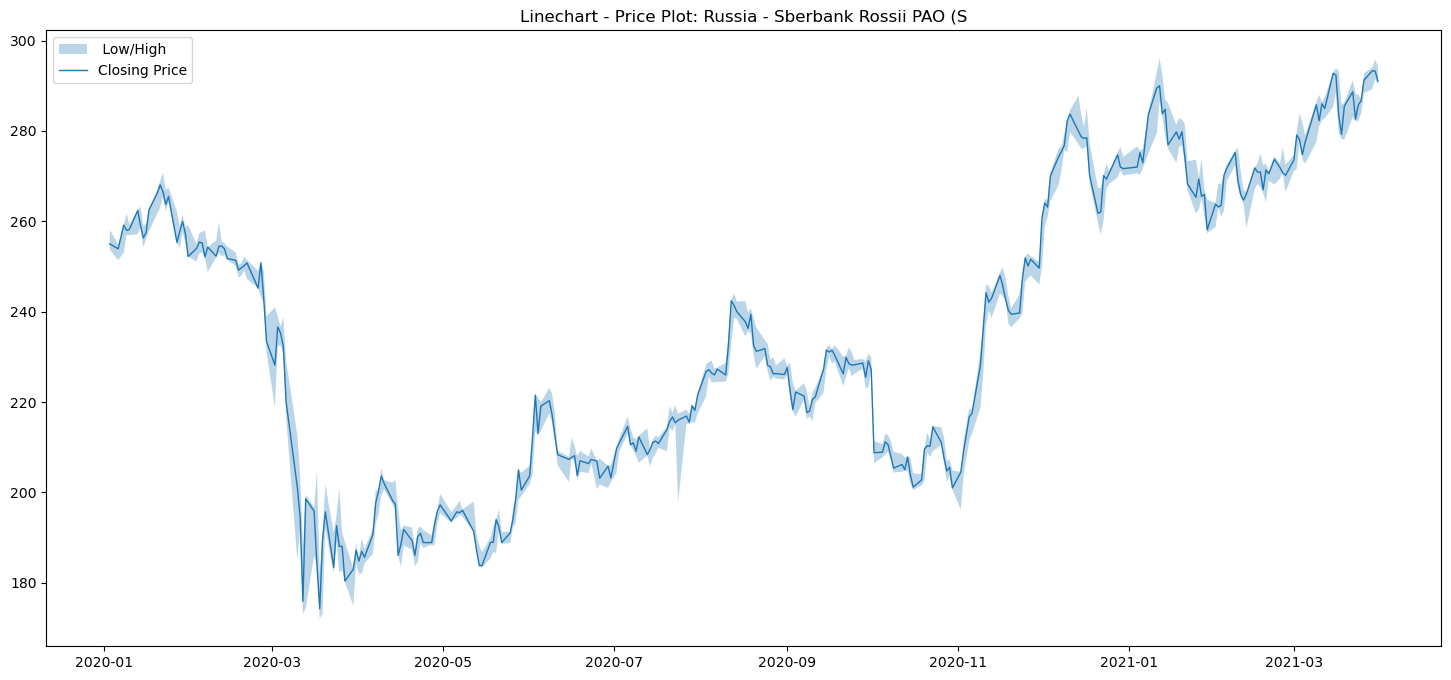

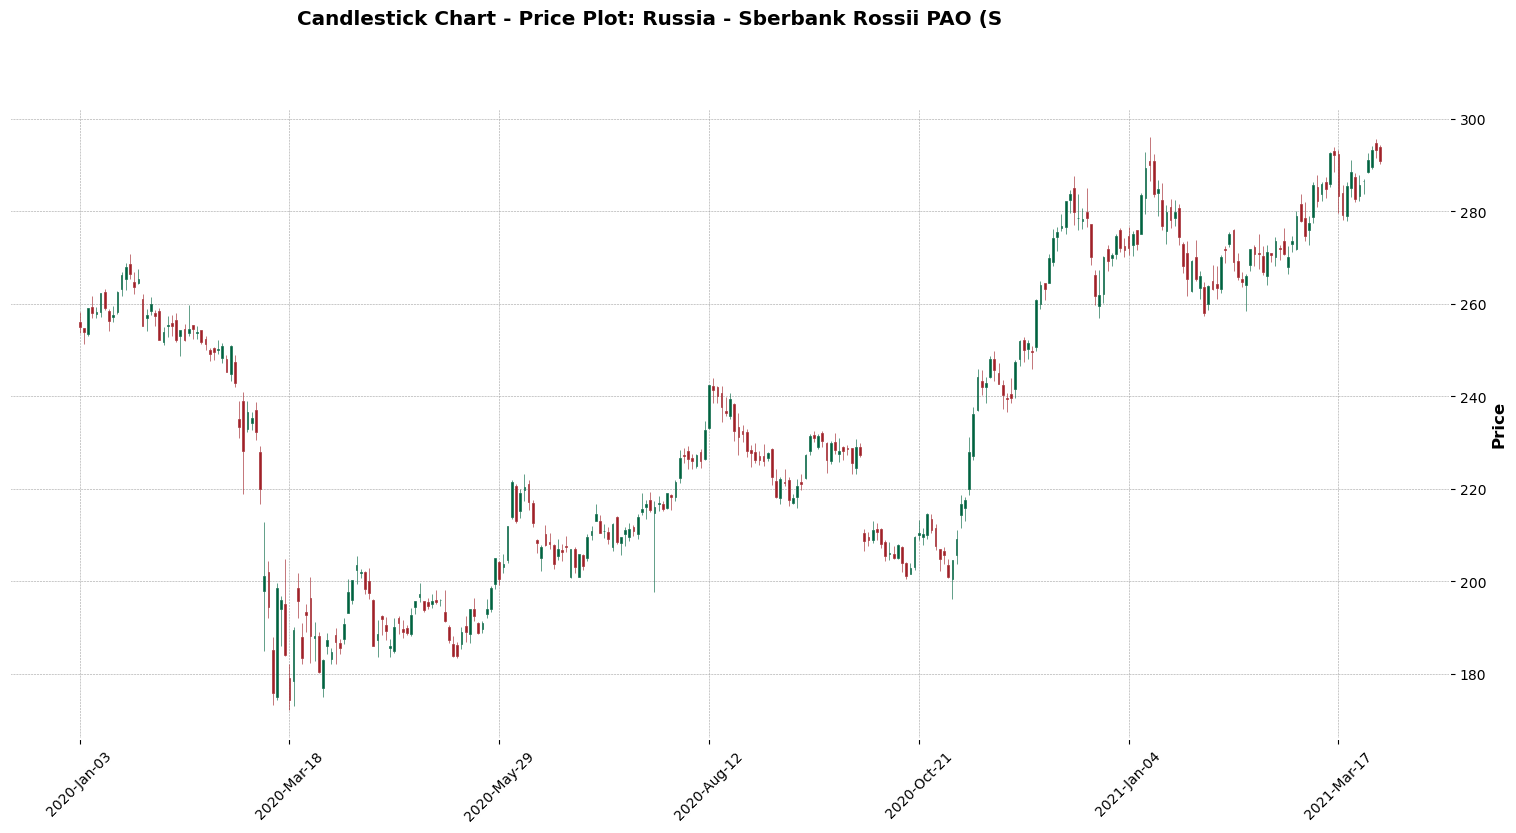

In [16]:
EDA_plot(df_rus,name =company_name[0])

In [17]:
from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly

from statsmodels.tsa.stattools import adfuller
from pmdarima.arima import auto_arima
from statsmodels.tsa.seasonal import seasonal_decompose
from pandas.tseries.offsets import DateOffset

20:35:26 - cmdstanpy - INFO - Chain [1] start processing
20:35:26 - cmdstanpy - INFO - Chain [1] done processing




Mean Absolute Percentage Error (MAPE): 16.77%


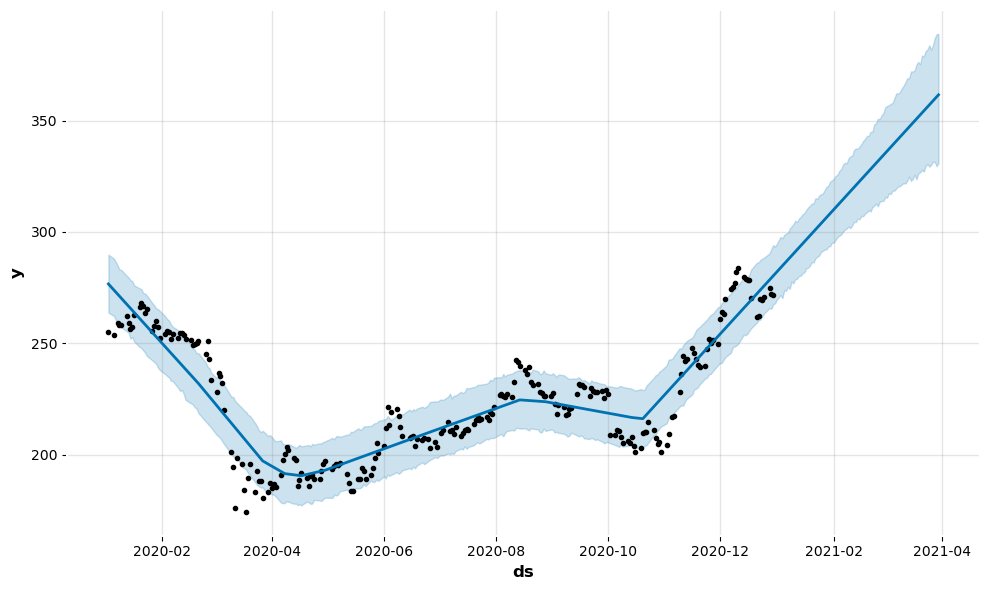

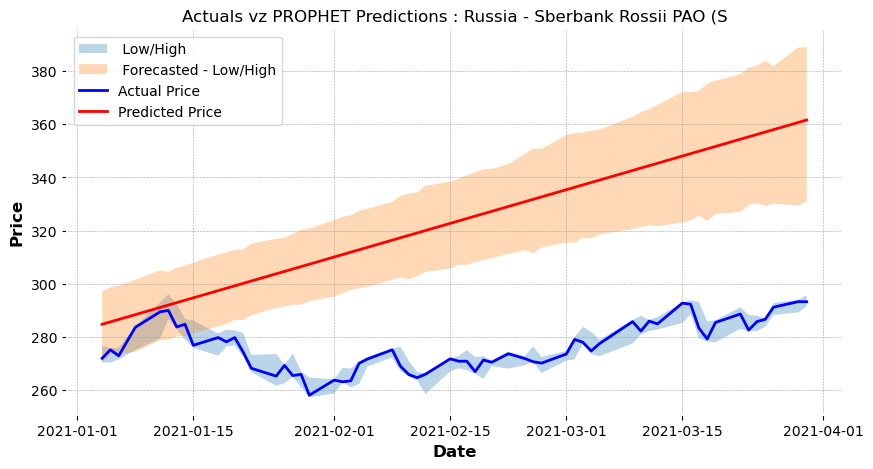

In [18]:
model_FP,forecast_FP = FB_Prop_Forecast(df_rus,name =company_name[0])

In [19]:
from statsmodels.tsa.stattools import adfuller
from pmdarima.arima import auto_arima
from statsmodels.tsa.seasonal import seasonal_decompose
from pandas.tseries.offsets import DateOffset
from statsmodels.tsa.arima.model import ARIMA

Train dataset shape: (250, 1)
Test dataset shape: (61, 1)
Test Statistic : -1.4233235279676009
p-value : 0.5710448680935883
#Lags Used : 8
Number of Observations Used : 241
The series is NOT stationary
ARIMA Order: (0, 1, 0)


Mean Absolute Percentage Error (MAPE): 2.91%


<Figure size 640x480 with 0 Axes>

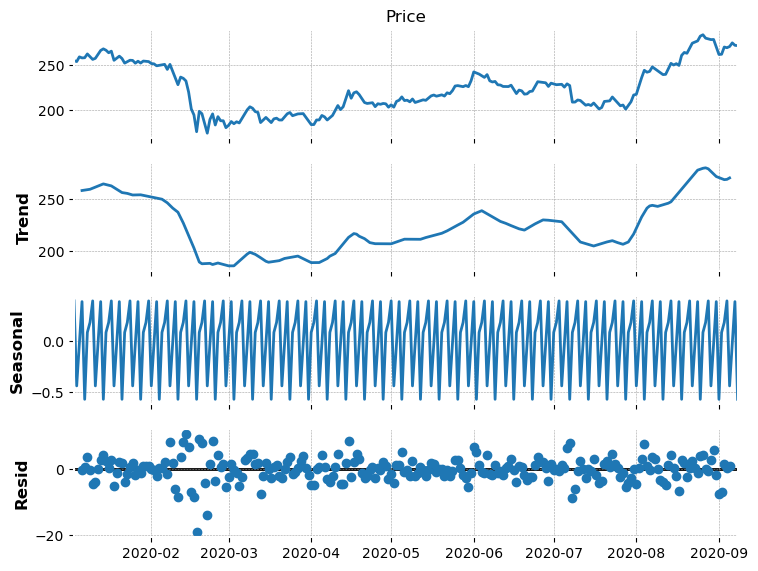

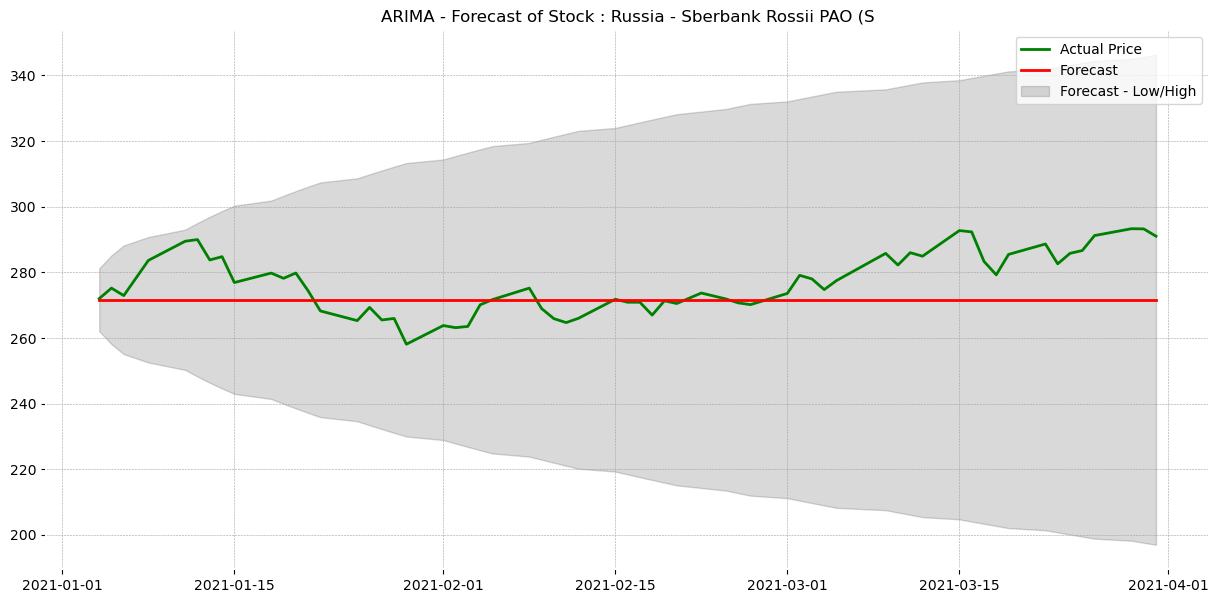

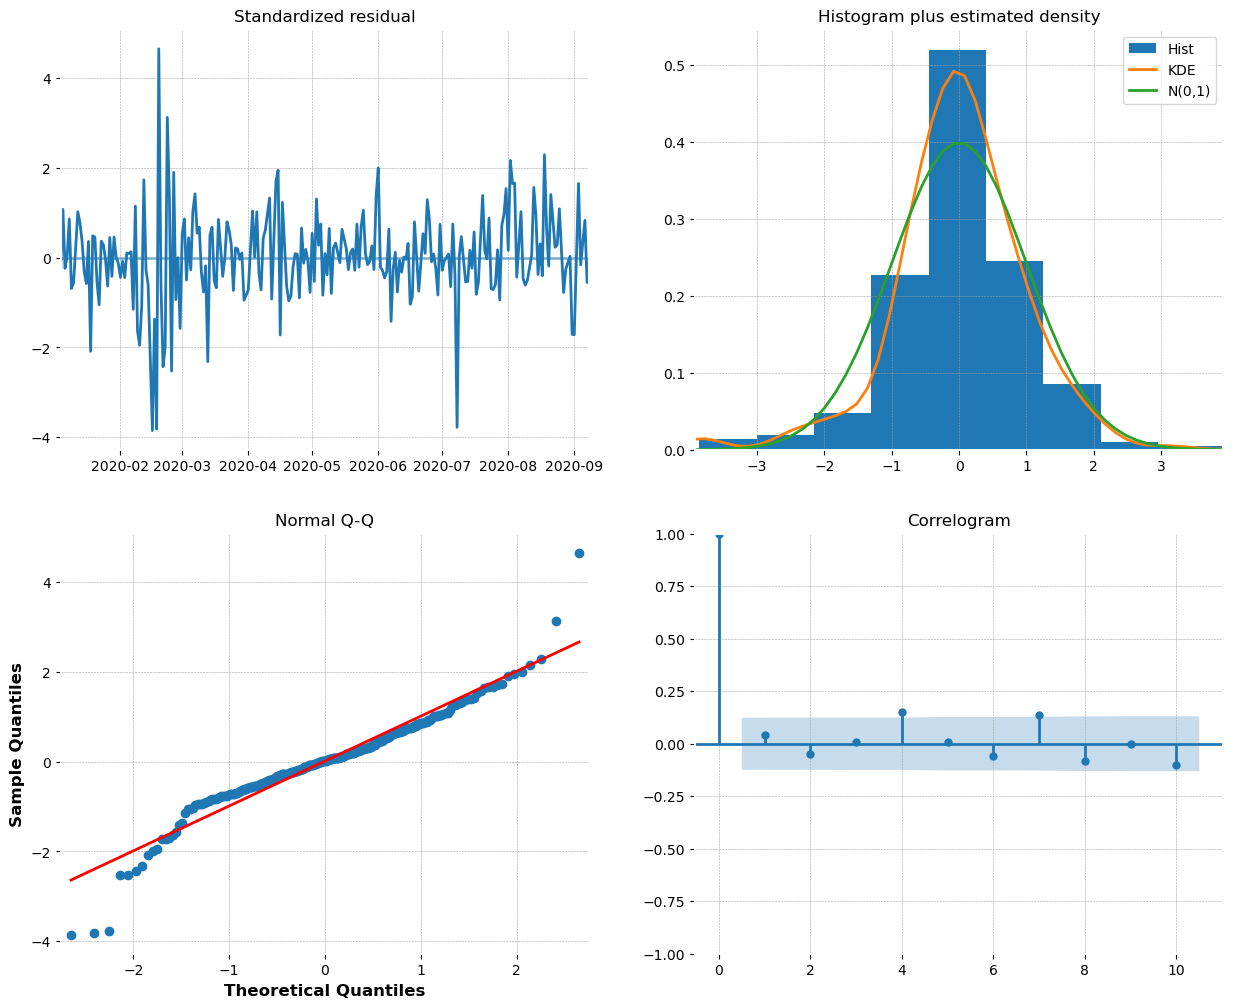

In [20]:
train_ARIMA, test_ARIMA, train_index, forecast_index = ARIMA_prerun(df_rus)

ARIMA_model,forecast_df = ARIMA_forecast(train_ARIMA, test_ARIMA, train_index, forecast_index,name=company_name[0])

ARIMA_model.plot_diagnostics(figsize=(15,12))
plt.show()

scaled price dataset (311, 1)
scaled tensor (305, 6, 1) (305, 1)
training (195, 6, 1) (195, 1)
validation (49, 6, 1) (49, 1)
test (61, 6, 1) (61, 1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.1681 - root_mean_squared_error: 0.4096 - val_loss: 0.2521 - val_root_mean_squared_error: 0.5021
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0717 - root_mean_squared_error: 0.2662 - val_loss: 0.0861 - val_root_mean_squared_error: 0.2934
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0171 - root_mean_squared_error: 0.1301 - val_loss: 0.0116 - val_root_mean_squared_error: 0.1076
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0138 - root_mean_squared_error: 0.1175 - val_loss: 0.0077 - val_root_mean_squared_error: 0.0880
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0119 - root_mean_squared_error: 0.1088 - val_loss: 0.0173 - val_root_mean_squared_error: 0.1316
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0071 - root_mean_squared_error: 0.0840 - val_loss: 0.0281 - val_root_mean_squared_error: 0.1676
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0073 - root_mean_

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0041 - root_mean_squared_error: 0.0641 - val_loss: 0.0083 - val_root_mean_squared_error: 0.0910
Epoch 45/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0043 - root_mean_squared_error: 0.0651 - val_loss: 0.0080 - val_root_mean_squared_error: 0.0892
Epoch 46/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0039 - root_mean_squared_error: 0.0618 - val_loss: 0.0081 - val_root_mean_squared_error: 0.0900
Epoch 47/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0040 - root_mean_squared_error: 0.0635 - val_loss: 0.0079 - val_root_mean_squared_error: 0.0887
Epoch 48/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0039 - root_mean_squared_error: 0.0621 - val_loss: 0.0093 - val_root_mean_squared_error: 0.0964
Epoch 49/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0044 - root_mean_squared_error: 0.0664 - val_loss: 0.0101 - val_root_mean_squared_error: 0.1004
Epoch 50/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0035 - root_mean_square

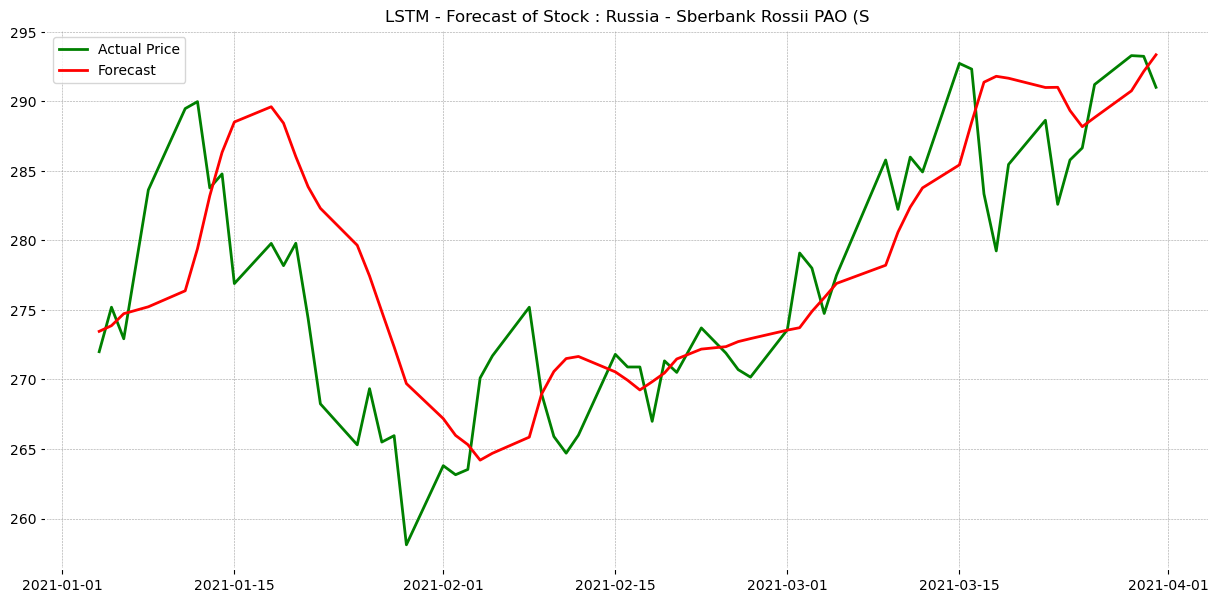

In [21]:
lstm_model_rus, forecast_lstm_rus = lstm(df_rus,name=company_name[0])

2021-01-25 00:00:00: Buy 376.93 stocks @ 265.30
2021-01-26 00:00:00: Hold stocks
2021-01-27 00:00:00: Hold stocks
2021-01-28 00:00:00: Hold stocks
2021-01-29 00:00:00: Hold stocks
2021-02-01 00:00:00: Hold stocks
2021-02-02 00:00:00: Hold stocks
2021-02-03 00:00:00: Hold stocks
2021-02-04 00:00:00: Hold stocks
2021-02-05 00:00:00: Hold stocks
2021-02-08 00:00:00: Hold stocks
2021-02-09 00:00:00: Hold stocks
2021-02-10 00:00:00: Hold stocks
2021-02-11 00:00:00: Hold stocks
2021-02-12 00:00:00: Hold stocks
2021-02-15 00:00:00: Hold stocks
2021-02-16 00:00:00: Hold stocks
2021-02-17 00:00:00: Hold stocks
2021-02-18 00:00:00: Hold stocks
2021-02-19 00:00:00: Hold stocks
2021-02-20 00:00:00: Hold stocks
2021-02-22 00:00:00: Hold stocks
2021-02-24 00:00:00: Hold stocks
2021-02-25 00:00:00: Hold stocks
2021-02-26 00:00:00: Hold stocks
2021-03-01 00:00:00: Hold stocks
2021-03-02 00:00:00: Hold stocks
2021-03-03 00:00:00: Hold stocks
2021-03-04 00:00:00: Hold stocks
2021-03-05 00:00:00: Hold st

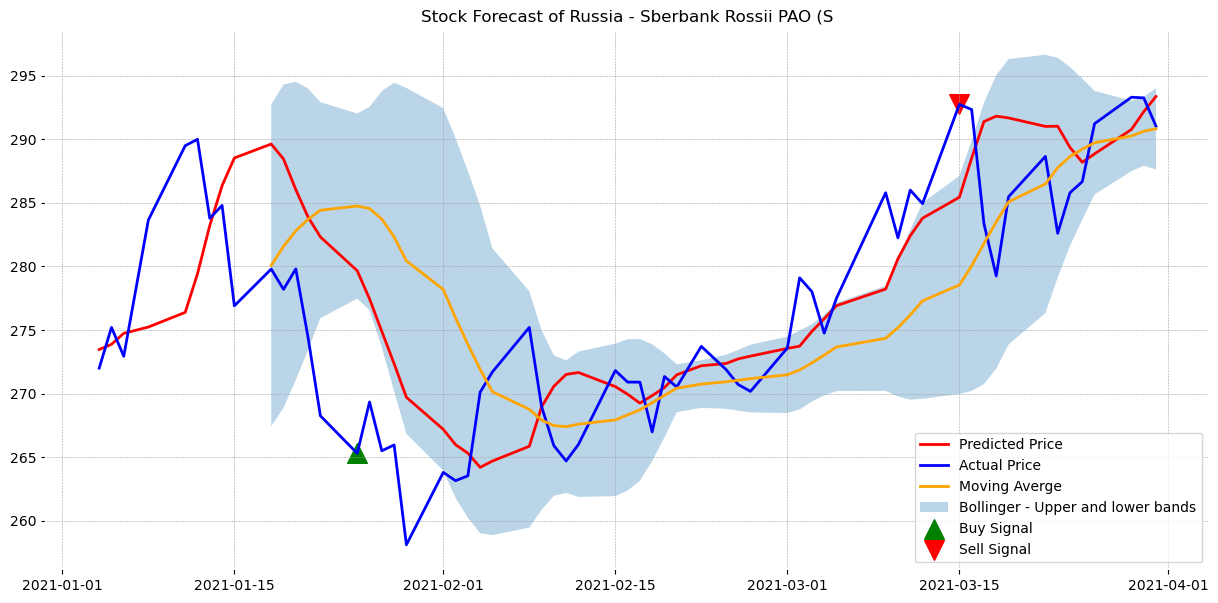

In [22]:
trading_algo(rolling_window=10,forecast=forecast_lstm_rus,stoploss=.1,initial_capital = 100000,LB_threshold = 0.001,max_hold=5,min_margin=0.08,name=company_name[0])

In [23]:
df_dic[company_name[1]].info()
print(df_dic[company_name[1]].tail())

<class 'pandas.core.frame.DataFrame'>
Index: 316 entries, 2021-03-31 00:00:00 to Highest: 25.48
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Price     316 non-null    object 
 1   Open      316 non-null    object 
 2   High      316 non-null    object 
 3   Low       316 non-null    object 
 4   Vol.      315 non-null    object 
 5   Change %  315 non-null    float64
dtypes: float64(1), object(5)
memory usage: 17.3+ KB
                             Price               Open            High  \
Date                                                                    
2020-01-07 00:00:00          19.93              20.22           20.28   
2020-01-06 00:00:00          20.08              20.34           20.34   
2020-01-03 00:00:00           20.3               20.3           20.44   
2020-01-02 00:00:00          20.38              20.42           20.44   
Highest: 25.48       Lowest: 12.38  Difference: 13.10  Average: 17.86

In [24]:
df_rus = ini_preprocess(df_dic[company_name[1]])

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 315 entries, 2020-01-02 to 2021-03-31
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Price     315 non-null    float64
 1   Open      315 non-null    float64
 2   High      315 non-null    float64
 3   Low       315 non-null    float64
 4   Vol.      315 non-null    float64
 5   Change %  315 non-null    float64
dtypes: float64(6)
memory usage: 17.2 KB
            Price   Open   High    Low        Vol.  Change %
Date                                                        
2021-03-25  20.02  20.50  20.86  20.02  15930000.0   -0.0148
2021-03-26  19.25  20.28  20.36  19.10  21350000.0   -0.0385
2021-03-29  19.10  19.24  19.67  19.10  16560000.0   -0.0078
2021-03-30  19.50  19.12  19.81  19.03  21050000.0    0.0209
2021-03-31  19.41  19.42  19.63  19.27  13140000.0   -0.0046


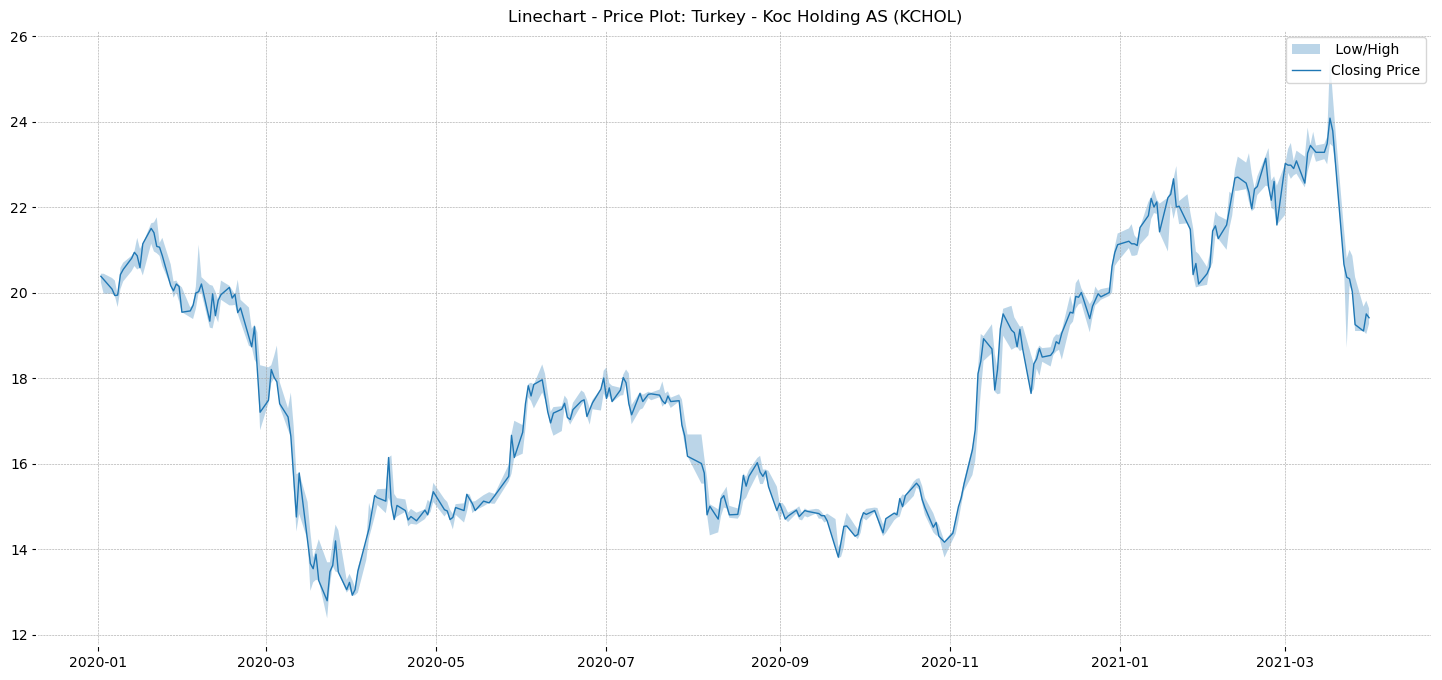

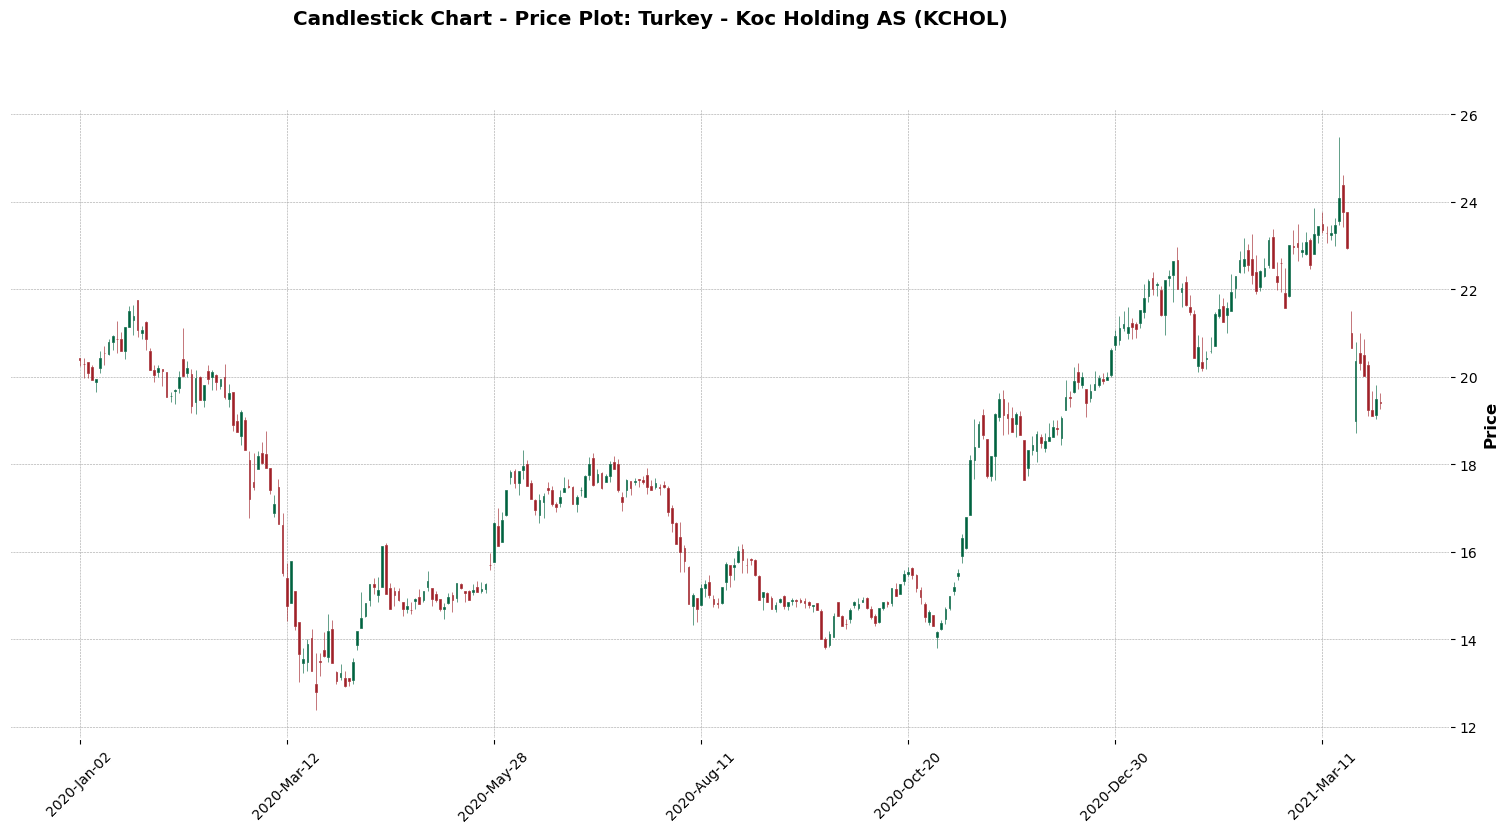

In [25]:
EDA_plot(df_rus,name =company_name[1])

20:35:32 - cmdstanpy - INFO - Chain [1] start processing
20:35:33 - cmdstanpy - INFO - Chain [1] done processing




Mean Absolute Percentage Error (MAPE): 10.81%


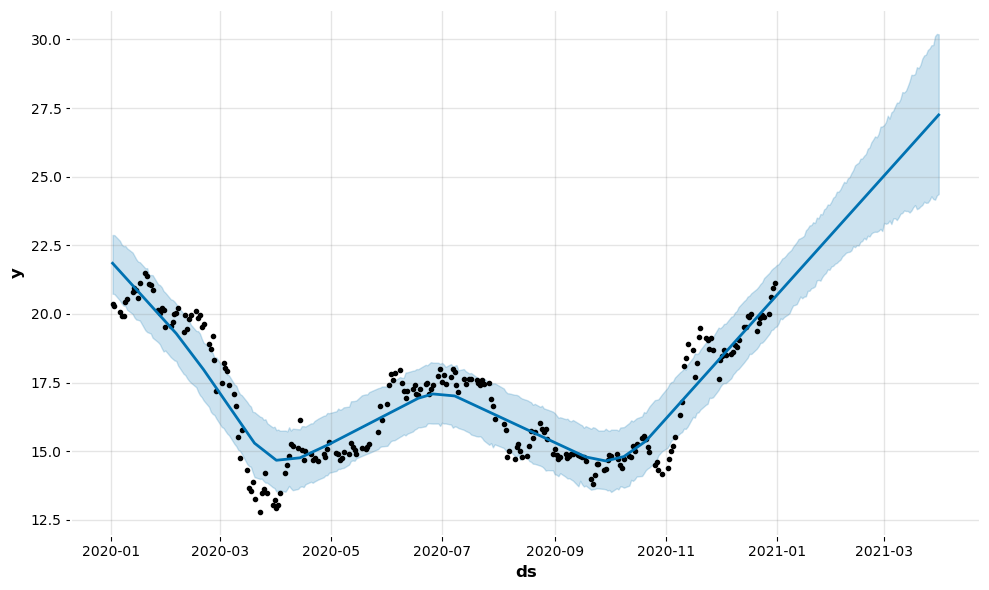

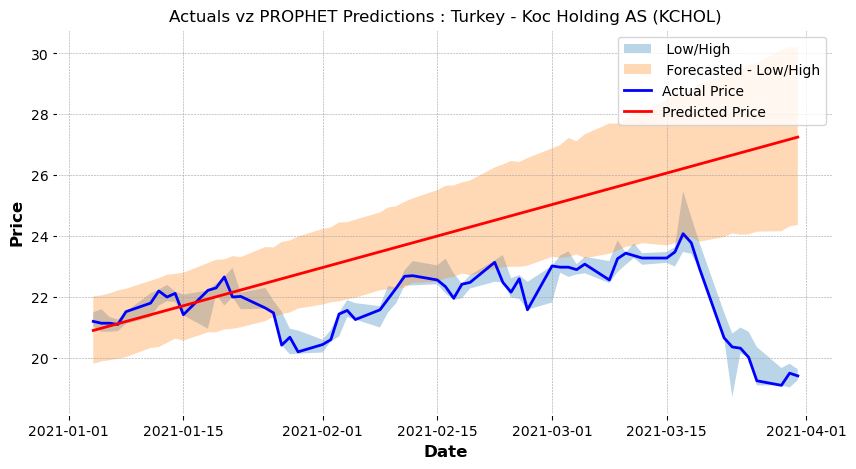

In [26]:
model_FP,forecast_FP = FB_Prop_Forecast(df_rus,name =company_name[1])

scaled price dataset (315, 1)
scaled tensor (309, 6, 1) (309, 1)
training (196, 6, 1) (196, 1)
validation (50, 6, 1) (50, 1)
test (63, 6, 1) (63, 1)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.1335 - root_mean_squared_error: 0.3650 - val_loss: 0.1269 - val_root_mean_squared_error: 0.3562
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0529 - root_mean_squared_error: 0.2292 - val_loss: 0.0365 - val_root_mean_squared_error: 0.1910
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0124 - root_mean_squared_error: 0.1107 - val_loss: 0.0074 - val_root_mean_squared_error: 0.0858
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0130 - root_mean_squared_error: 0.1140 - val_loss: 0.0066 - val_root_mean_squared_error: 0.0810
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0096 - root_mean_squared_error: 0.0978 - val_loss: 0.0114 - val_root_mean_squared_error: 0.1066
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0059 - root_mean_squared_error: 0.0767 - val_loss: 0.0157 - val_root_mean_squared_error: 0.1254
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0063 - root_mean_

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0030 - root_mean_squared_error: 0.0546 - val_loss: 0.0077 - val_root_mean_squared_error: 0.0875
Epoch 45/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0026 - root_mean_squared_error: 0.0508 - val_loss: 0.0071 - val_root_mean_squared_error: 0.0841
Epoch 46/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0026 - root_mean_squared_error: 0.0505 - val_loss: 0.0067 - val_root_mean_squared_error: 0.0817
Epoch 47/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0029 - root_mean_squared_error: 0.0543 - val_loss: 0.0079 - val_root_mean_squared_error: 0.0891
Epoch 48/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0030 - root_mean_squared_error: 0.0543 - val_loss: 0.0062 - val_root_mean_squared_error: 0.0785
Epoch 49/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0029 - root_mean_squared_error: 0.0539 - val_loss: 0.0073 - val_root_mean_squared_error: 0.0856
Epoch 50/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0028 - root_mean_square

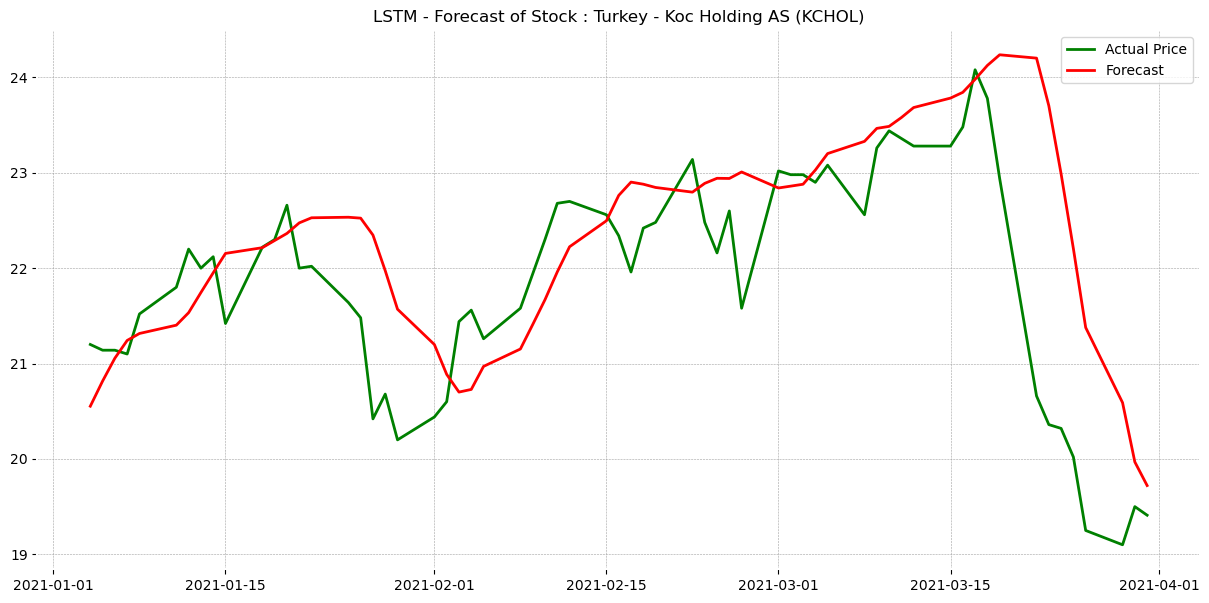

In [27]:
lstm_model_rus, forecast_lstm_rus = lstm(df_rus,name=company_name[1])

2021-01-27 00:00:00: Buy 48.97 stocks @ 20.42
2021-01-28 00:00:00: Hold stocks
2021-01-29 00:00:00: Hold stocks
2021-02-01 00:00:00: Hold stocks
2021-02-02 00:00:00: Hold stocks
2021-02-03 00:00:00: Hold stocks
2021-02-04 00:00:00: Hold stocks
2021-02-05 00:00:00: Hold stocks
2021-02-08 00:00:00: Hold stocks
2021-02-09 00:00:00: Hold stocks
2021-02-10 00:00:00: Sell @ 22.3
Estimated Returns:1092.07, Estimated Gain/Loss:92.07
2021-03-22 00:00:00: Buy 52.86 stocks @ 20.66
2021-03-23 00:00:00: Hold stocks
2021-03-24 00:00:00: Hold stocks
2021-03-25 00:00:00: Hold stocks
2021-03-26 00:00:00: Hold stocks
2021-03-29 00:00:00: Hold stocks
2021-03-30 00:00:00: Hold stocks
2021-03-31 00:00:00: Hold stocks
Return of capital is 9.2%


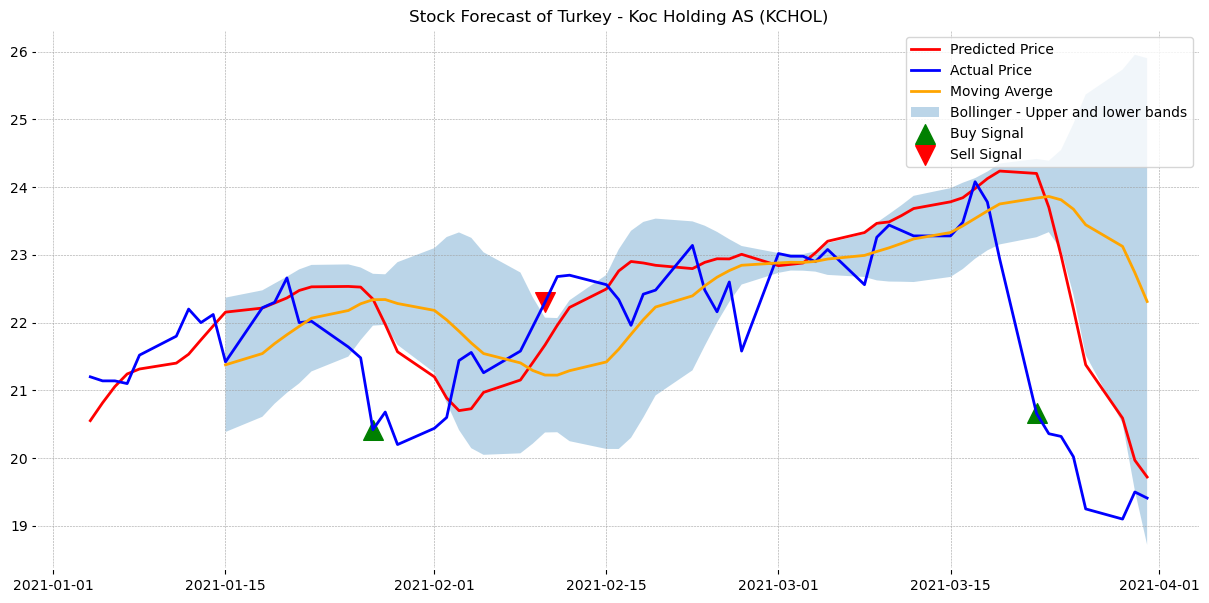

In [28]:
trading_algo(rolling_window=10,forecast=forecast_lstm_rus,stoploss=.1,initial_capital = 1000,LB_threshold = 0.001,max_hold=5,min_margin=0.08,name=company_name[1])

In [29]:
df_dic[company_name[2]].info()
print(df_dic[company_name[2]].tail())

<class 'pandas.core.frame.DataFrame'>
Index: 306 entries, 2021-03-31 00:00:00 to Highest: 4.92
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Price     306 non-null    object 
 1   Open      306 non-null    object 
 2   High      306 non-null    object 
 3   Low       306 non-null    object 
 4   Vol.      305 non-null    object 
 5   Change %  305 non-null    float64
dtypes: float64(1), object(5)
memory usage: 16.7+ KB
                            Price              Open           High  \
Date                                                                 
2020-01-08 00:00:00          4.41              4.19           4.59   
2020-01-06 00:00:00          4.28              4.16           4.44   
2020-01-05 00:00:00          4.41               4.7            4.7   
2020-01-02 00:00:00          4.81              4.81           4.87   
Highest: 4.92        Lowest: 2.40  Difference: 2.52  Average: 3.55   

                 

In [30]:
df_egypt = ini_preprocess(df_dic[company_name[2]])

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 305 entries, 2020-01-02 to 2021-03-31
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Price     305 non-null    float64
 1   Open      305 non-null    float64
 2   High      305 non-null    float64
 3   Low       305 non-null    float64
 4   Vol.      305 non-null    float64
 5   Change %  305 non-null    float64
dtypes: float64(6)
memory usage: 16.7 KB
            Price  Open  High   Low       Vol.  Change %
Date                                                    
2021-03-25   3.71  3.62  3.78  3.59  2500000.0    0.0137
2021-03-28   3.71  3.76  3.76  3.68  2340000.0    0.0000
2021-03-29   3.70  3.69  3.73  3.68  1250000.0   -0.0027
2021-03-30   3.73  3.71  3.76  3.67  3430000.0    0.0081
2021-03-31   3.75  3.74  3.82  3.71  1570000.0    0.0054


scaled price dataset (305, 1)
scaled tensor (299, 6, 1) (299, 1)
training (189, 6, 1) (189, 1)
validation (48, 6, 1) (48, 1)
test (62, 6, 1) (62, 1)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.1694 - root_mean_squared_error: 0.4103 - val_loss: 0.1070 - val_root_mean_squared_error: 0.3271
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0545 - root_mean_squared_error: 0.2332 - val_loss: 0.0214 - val_root_mean_squared_error: 0.1463
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0191 - root_mean_squared_error: 0.1381 - val_loss: 0.0039 - val_root_mean_squared_error: 0.0628
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0186 - root_mean_squared_error: 0.1361 - val_loss: 0.0073 - val_root_mean_squared_error: 0.0851
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0162 - root_mean_squared_error: 0.1272 - val_loss: 0.0018 - val_root_mean_squared_error: 0.0420
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0097 - root_mean_squared_error: 0.0984 - val_loss: 0.0061 - val_root_mean_squared_error: 0.0781
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0094 - root_me

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0041 - root_mean_squared_error: 0.0640 - val_loss: 0.0022 - val_root_mean_squared_error: 0.0473
Epoch 45/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0051 - root_mean_squared_error: 0.0710 - val_loss: 0.0027 - val_root_mean_squared_error: 0.0516
Epoch 46/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0049 - root_mean_squared_error: 0.0700 - val_loss: 0.0027 - val_root_mean_squared_error: 0.0515
Epoch 47/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0042 - root_mean_squared_error: 0.0643 - val_loss: 0.0022 - val_root_mean_squared_error: 0.0468
Epoch 48/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0043 - root_mean_squared_error: 0.0658 - val_loss: 0.0027 - val_root_mean_squared_error: 0.0524
Epoch 49/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0041 - root_mean_squared_error: 0.0639 - val_loss: 0.0026 - val_root_mean_squared_error: 0.0506
Epoch 50/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0050 - root_mean_square

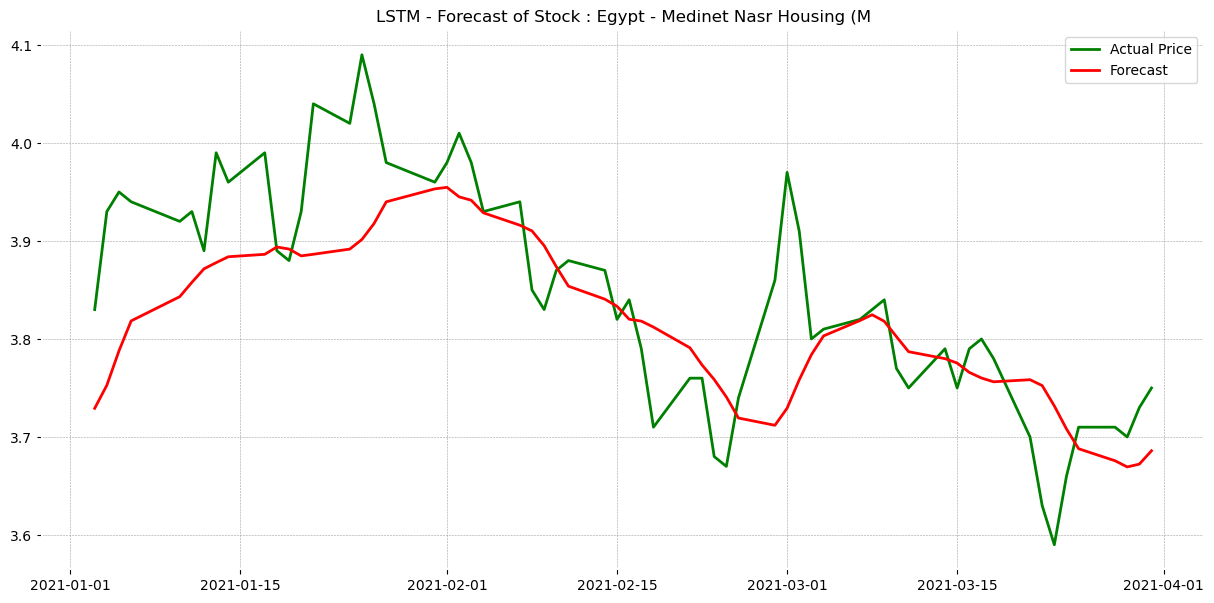

In [31]:
lstm_model_egypt, forecast_lstm_egypt = lstm(df_egypt,name=company_name[2])

2021-02-09 00:00:00: Buy 26109.66 stocks @ 3.83
2021-02-10 00:00:00: Hold stocks
2021-02-11 00:00:00: Hold stocks
2021-02-14 00:00:00: Hold stocks
2021-02-15 00:00:00: Hold stocks
2021-02-16 00:00:00: Hold stocks
2021-02-17 00:00:00: Hold stocks
2021-02-18 00:00:00: Hold stocks
2021-02-21 00:00:00: Hold stocks
2021-02-22 00:00:00: Hold stocks
2021-02-23 00:00:00: Hold stocks
2021-02-24 00:00:00: Hold stocks
2021-02-25 00:00:00: Hold stocks
2021-02-28 00:00:00: Hold stocks
2021-03-01 00:00:00: Sell @ 3.97
Estimated Returns:103655.35, Estimated Gain/Loss:3655.35
2021-03-22 00:00:00: Buy 28555.19 stocks @ 3.63
2021-03-23 00:00:00: Hold stocks
2021-03-24 00:00:00: Hold stocks
2021-03-25 00:00:00: Sell @ 3.7100000000000004
Estimated Returns:105939.77, Estimated Gain/Loss:5939.77
Return of capital is 5.9%


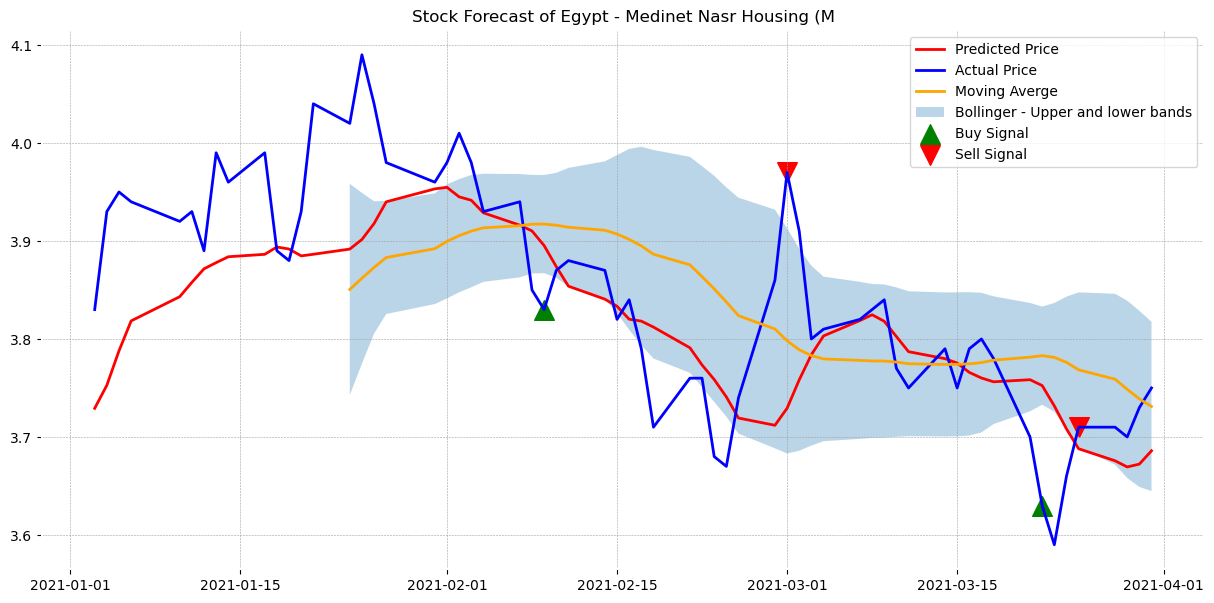

In [32]:
trading_algo(rolling_window=15,forecast=forecast_lstm_egypt,stoploss=.1,initial_capital = 100000,LB_threshold = 0.001,max_hold=5,min_margin=0.01,name=company_name[2])

In [33]:
df_dic[company_name[3]].info()
print(df_dic[company_name[3]].tail())
name = company_name[3]

<class 'pandas.core.frame.DataFrame'>
Index: 310 entries, 2021-03-31 00:00:00 to Highest: 15.30
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Price     310 non-null    object 
 1   Open      310 non-null    object 
 2   High      310 non-null    object 
 3   Low       310 non-null    object 
 4   Vol.      309 non-null    object 
 5   Change %  309 non-null    float64
dtypes: float64(1), object(5)
memory usage: 17.0+ KB
                            Price              Open            High  \
Date                                                                  
2020-01-07 00:00:00         13.48             13.03           13.48   
2020-01-06 00:00:00         12.89              12.9           12.91   
2020-01-03 00:00:00          12.9             12.45           12.93   
2020-01-02 00:00:00         12.57             12.88           12.99   
Highest: 15.30       Lowest: 5.81  Difference: 9.49  Average: 11.38   

         

In [34]:
df_br= ini_preprocess(df_dic[company_name[3]])

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 309 entries, 2020-01-02 to 2021-03-31
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Price     309 non-null    float64
 1   Open      309 non-null    float64
 2   High      309 non-null    float64
 3   Low       309 non-null    float64
 4   Vol.      309 non-null    float64
 5   Change %  309 non-null    float64
dtypes: float64(6)
memory usage: 16.9 KB
            Price   Open   High    Low        Vol.  Change %
Date                                                        
2021-03-25   9.80  10.01  10.01   9.66   8880000.0   -0.0151
2021-03-26   9.83   9.80   9.94   9.70   5110000.0    0.0031
2021-03-29  10.47   9.85  10.50   9.81  22040000.0    0.0651
2021-03-30  10.36  10.41  10.62  10.30   9930000.0   -0.0105
2021-03-31  10.20  10.35  10.40  10.12   7770000.0   -0.0154


scaled price dataset (309, 1)
scaled tensor (303, 6, 1) (303, 1)
training (194, 6, 1) (194, 1)
validation (49, 6, 1) (49, 1)
test (60, 6, 1) (60, 1)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.4253 - root_mean_squared_error: 0.6518 - val_loss: 0.0789 - val_root_mean_squared_error: 0.2809
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1875 - root_mean_squared_error: 0.4320 - val_loss: 0.0096 - val_root_mean_squared_error: 0.0982
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0385 - root_mean_squared_error: 0.1936 - val_loss: 0.0150 - val_root_mean_squared_error: 0.1226
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0253 - root_mean_squared_error: 0.1579 - val_loss: 0.0249 - val_root_mean_squared_error: 0.1579
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0196 - root_mean_squared_error: 0.1397 - val_loss: 0.0038 - val_root_mean_squared_error: 0.0620
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0118 - root_mean_squared_error: 0.1084 - val_loss: 0.0012 - val_root_mean_squared_error: 0.0345
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0132 - root_mean_

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0083 - root_mean_squared_error: 0.0910 - val_loss: 0.0014 - val_root_mean_squared_error: 0.0375
Epoch 45/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0076 - root_mean_squared_error: 0.0869 - val_loss: 0.0013 - val_root_mean_squared_error: 0.0362
Epoch 46/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0094 - root_mean_squared_error: 0.0962 - val_loss: 0.0013 - val_root_mean_squared_error: 0.0357
Epoch 47/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0079 - root_mean_squared_error: 0.0886 - val_loss: 0.0012 - val_root_mean_squared_error: 0.0346
Epoch 48/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0071 - root_mean_squared_error: 0.0840 - val_loss: 0.0019 - val_root_mean_squared_error: 0.0436
Epoch 49/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0088 - root_mean_squared_error: 0.0938 - val_loss: 0.0015 - val_root_mean_squared_error: 0.0383
Epoch 50/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0065 - root_mean_square

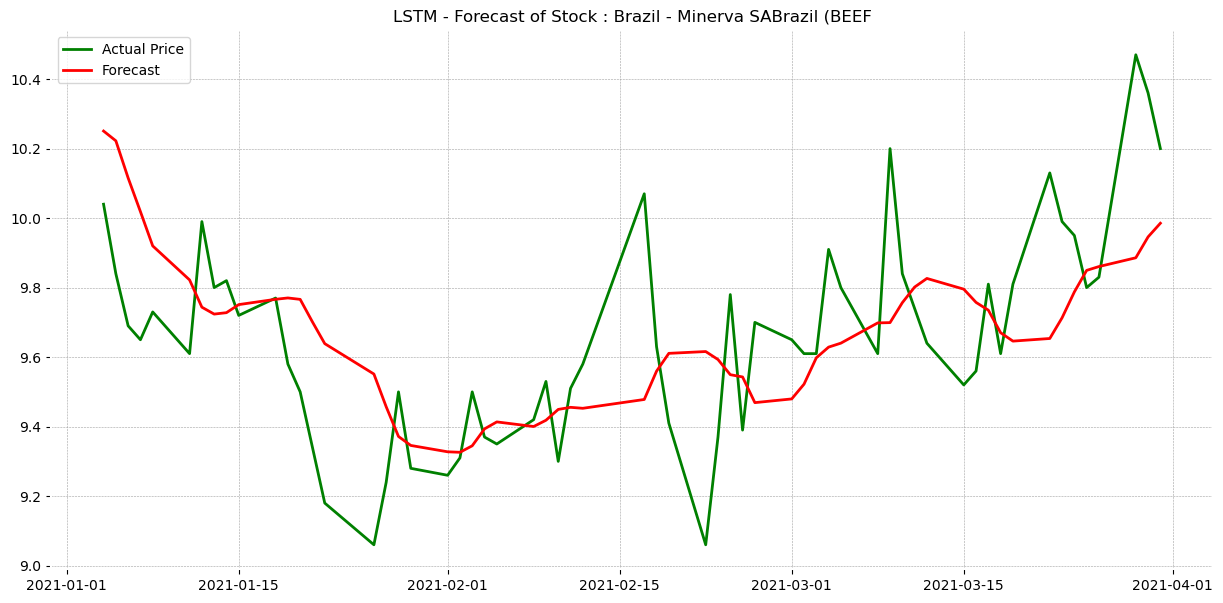

In [35]:
lstm_model_br, forecast_lstm_br = lstm(df_br,name=company_name[3])

2021-01-26 00:00:00: Buy 5518.76 stocks @ 9.06
2021-01-27 00:00:00: Hold stocks
2021-01-28 00:00:00: Hold stocks
2021-01-29 00:00:00: Hold stocks
2021-02-01 00:00:00: Hold stocks
2021-02-02 00:00:00: Hold stocks
2021-02-03 00:00:00: Hold stocks
2021-02-04 00:00:00: Hold stocks
2021-02-05 00:00:00: Hold stocks
2021-02-08 00:00:00: Hold stocks
2021-02-09 00:00:00: Hold stocks
2021-02-10 00:00:00: Hold stocks
2021-02-11 00:00:00: Hold stocks
2021-02-12 00:00:00: Hold stocks
2021-02-17 00:00:00: Sell @ 10.07
Estimated Returns:55573.95, Estimated Gain/Loss:5573.95
Return of capital is 11.1%


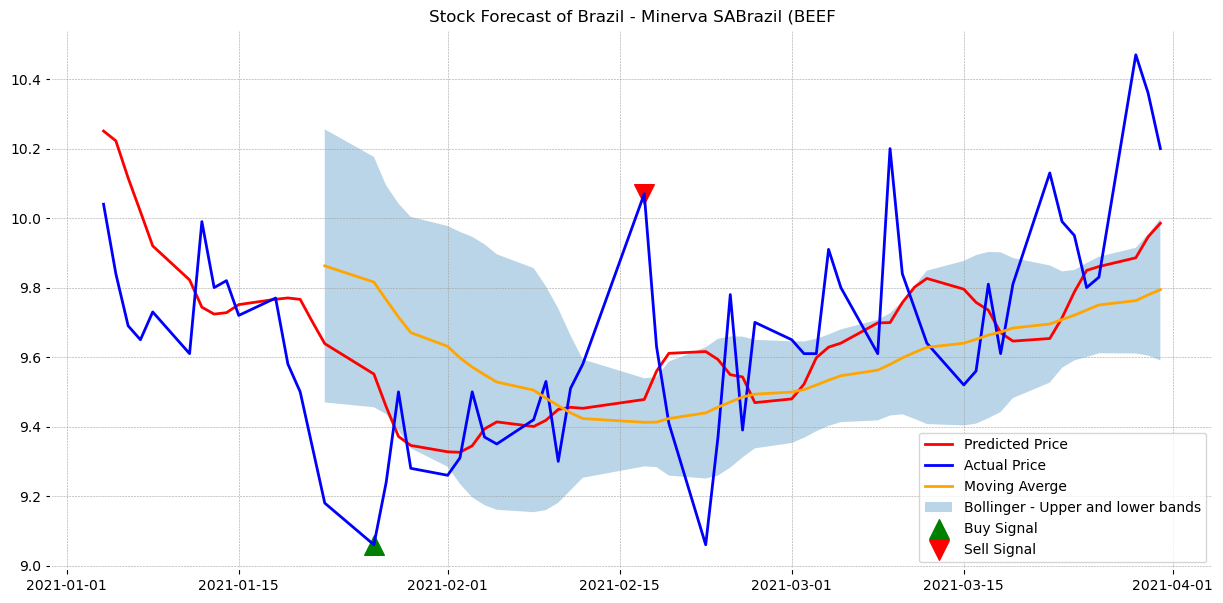

In [36]:
trading_algo(rolling_window=15,forecast=forecast_lstm_br,stoploss=.1,initial_capital=50000,LB_threshold = 0.001,max_hold=5,min_margin=0.1,name=company_name[3])

In [40]:
df_dic[company_name[4]].info()
print(df_dic[company_name[4]].tail())
name = company_name[4]

<class 'pandas.core.frame.DataFrame'>
Index: 301 entries, 2021-03-31 00:00:00 to Highest: 90.000
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Price     301 non-null    object 
 1   Open      301 non-null    object 
 2   High      301 non-null    object 
 3   Low       301 non-null    object 
 4   Vol.      300 non-null    object 
 5   Change %  300 non-null    float64
dtypes: float64(1), object(5)
memory usage: 16.5+ KB
                              Price                Open             High  \
Date                                                                       
2020-01-07 00:00:00            47.6               48.35               49   
2020-01-06 00:00:00            48.5                48.4             48.7   
2020-01-03 00:00:00            48.8               48.25            49.45   
2020-01-02 00:00:00           48.25               49.35             50.2   
Highest: 90.000      Lowest: 32.000  Difference: 5

In [41]:
df_br= ini_preprocess(df_dic[company_name[4]])

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 300 entries, 2020-01-02 to 2021-03-31
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Price     300 non-null    float64
 1   Open      300 non-null    float64
 2   High      300 non-null    float64
 3   Low       300 non-null    float64
 4   Vol.      300 non-null    float64
 5   Change %  300 non-null    float64
dtypes: float64(6)
memory usage: 16.4 KB
            Price   Open   High    Low      Vol.  Change %
Date                                                      
2021-03-25  83.60  85.20  87.30  82.10  389780.0   -0.0313
2021-03-26  81.85  84.00  84.60  80.70  462550.0   -0.0209
2021-03-29  85.00  80.00  86.00  79.00  371220.0    0.0385
2021-03-30  86.10  85.15  86.75  84.60  141400.0    0.0129
2021-03-31  85.15  86.50  88.10  85.15  564300.0   -0.0110


scaled price dataset (300, 1)
scaled tensor (294, 6, 1) (294, 1)
training (187, 6, 1) (187, 1)
validation (47, 6, 1) (47, 1)
test (60, 6, 1) (60, 1)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.1535 - root_mean_squared_error: 0.3915 - val_loss: 0.5981 - val_root_mean_squared_error: 0.7734
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0752 - root_mean_squared_error: 0.2741 - val_loss: 0.3268 - val_root_mean_squared_error: 0.5717
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0357 - root_mean_squared_error: 0.1881 - val_loss: 0.1206 - val_root_mean_squared_error: 0.3473
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0121 - root_mean_squared_error: 0.1097 - val_loss: 0.0178 - val_root_mean_squared_error: 0.1336
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0107 - root_mean_squared_error: 0.1032 - val_loss: 0.0079 - val_root_mean_squared_error: 0.0887
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0108 - root_mean_squared_error: 0.1037 - val_loss: 0.0230 - val_root_mean_squared_error: 0.1516
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0068 - root_m

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0026 - root_mean_squared_error: 0.0510 - val_loss: 0.0426 - val_root_mean_squared_error: 0.2063
Epoch 45/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0027 - root_mean_squared_error: 0.0521 - val_loss: 0.0467 - val_root_mean_squared_error: 0.2162
Epoch 46/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0023 - root_mean_squared_error: 0.0479 - val_loss: 0.0424 - val_root_mean_squared_error: 0.2060
Epoch 47/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0025 - root_mean_squared_error: 0.0503 - val_loss: 0.0393 - val_root_mean_squared_error: 0.1982
Epoch 48/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0029 - root_mean_squared_error: 0.0539 - val_loss: 0.0467 - val_root_mean_squared_error: 0.2161
Epoch 49/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0025 - root_mean_squared_error: 0.0498 - val_loss: 0.0469 - val_root_mean_squared_error: 0.2166
Epoch 50/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0026 - root_mean_square

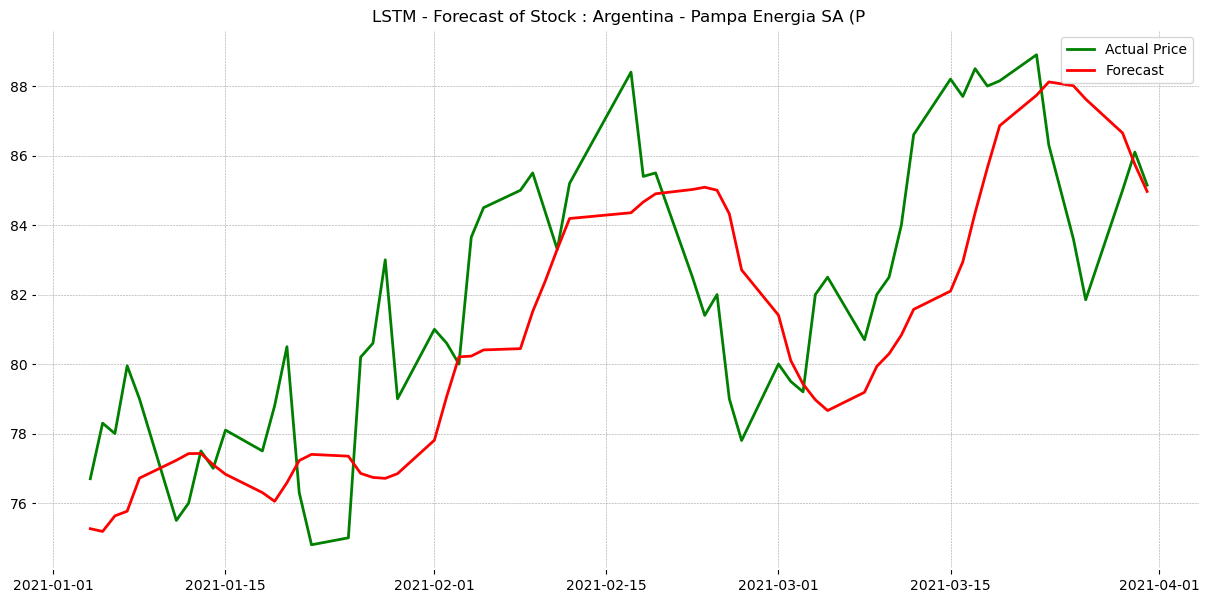

In [42]:
lstm_model_br, forecast_lstm_br = lstm(df_br,name=company_name[4])

2021-01-25 00:00:00: Buy 666.67 stocks @ 75.00
2021-01-26 00:00:00: Hold stocks
2021-01-27 00:00:00: Hold stocks
2021-01-28 00:00:00: Sell @ 83.0
Estimated Returns:55333.33, Estimated Gain/Loss:5333.33
2021-02-26 00:00:00: Buy 711.23 stocks @ 77.80
2021-03-01 00:00:00: Hold stocks
2021-03-02 00:00:00: Hold stocks
2021-03-03 00:00:00: Hold stocks
2021-03-04 00:00:00: Hold stocks
2021-03-05 00:00:00: Hold stocks
2021-03-08 00:00:00: Hold stocks
2021-03-09 00:00:00: Hold stocks
2021-03-10 00:00:00: Hold stocks
2021-03-11 00:00:00: Hold stocks
2021-03-12 00:00:00: Sell @ 86.6
Estimated Returns:61592.12, Estimated Gain/Loss:11592.12
Return of capital is 23.2%


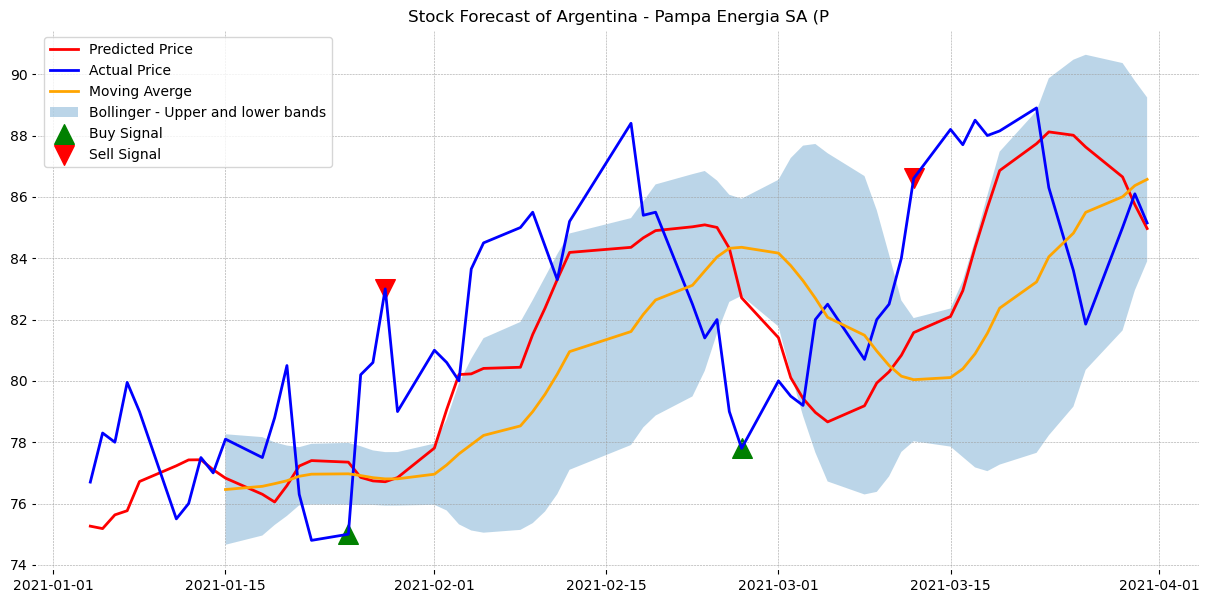

In [43]:
trading_algo(rolling_window=10,forecast=forecast_lstm_br,stoploss=.1,initial_capital=50000,LB_threshold = 0.001,max_hold=5,min_margin=0.1,name=company_name[4])

In [44]:
df_dic[company_name[5]].info()
print(df_dic[company_name[5]].tail())
name = company_name[5]

<class 'pandas.core.frame.DataFrame'>
Index: 304 entries, 2021-03-31 00:00:00 to Highest: 7,300.0
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Price     304 non-null    object 
 1   Open      304 non-null    object 
 2   High      304 non-null    object 
 3   Low       304 non-null    object 
 4   Vol.      303 non-null    object 
 5   Change %  303 non-null    float64
dtypes: float64(1), object(5)
memory usage: 16.6+ KB
                               Price                 Open              High  \
Date                                                                          
2020-01-08 00:00:00             6880                 6940              6950   
2020-01-07 00:00:00             6950                 6950              6950   
2020-01-03 00:00:00             7000                 7040              7100   
2020-01-02 00:00:00             7120                 7300              7300   
Highest: 7,300.0     Lowest: 2,

In [45]:
df_br= ini_preprocess(df_dic[company_name[5]])

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 303 entries, 2020-01-02 to 2021-03-31
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Price     303 non-null    float64
 1   Open      303 non-null    float64
 2   High      303 non-null    float64
 3   Low       303 non-null    float64
 4   Vol.      303 non-null    float64
 5   Change %  303 non-null    float64
dtypes: float64(6)
memory usage: 16.6 KB
             Price    Open    High     Low      Vol.  Change %
Date                                                          
2021-03-25  5030.0  5035.0  5045.0  4950.0  317060.0    0.0010
2021-03-26  5020.0  5085.0  5085.0  4980.0  203460.0   -0.0020
2021-03-29  5045.0  5020.0  5045.0  5015.0  117540.0    0.0050
2021-03-30  5100.0  5010.0  5100.0  5010.0  583700.0    0.0109
2021-03-31  5150.0  5100.0  5170.0  5100.0  212440.0    0.0098


scaled price dataset (303, 1)
scaled tensor (297, 6, 1) (297, 1)
training (188, 6, 1) (188, 1)
validation (48, 6, 1) (48, 1)
test (61, 6, 1) (61, 1)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.2329 - root_mean_squared_error: 0.4825 - val_loss: 0.2170 - val_root_mean_squared_error: 0.4658
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1286 - root_mean_squared_error: 0.3579 - val_loss: 0.0899 - val_root_mean_squared_error: 0.2998
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0441 - root_mean_squared_error: 0.2085 - val_loss: 0.0157 - val_root_mean_squared_error: 0.1251
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0113 - root_mean_squared_error: 0.1061 - val_loss: 0.0040 - val_root_mean_squared_error: 0.0635
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0165 - root_mean_squared_error: 0.1284 - val_loss: 0.0032 - val_root_mean_squared_error: 0.0570
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0129 - root_mean_squared_error: 0.1132 - val_loss: 0.0054 - val_root_mean_squared_error: 0.0733
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0083 - root_m

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0043 - root_mean_squared_error: 0.0651 - val_loss: 0.0036 - val_root_mean_squared_error: 0.0604
Epoch 45/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0044 - root_mean_squared_error: 0.0660 - val_loss: 0.0044 - val_root_mean_squared_error: 0.0662
Epoch 46/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0053 - root_mean_squared_error: 0.0724 - val_loss: 0.0040 - val_root_mean_squared_error: 0.0634
Epoch 47/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0042 - root_mean_squared_error: 0.0647 - val_loss: 0.0035 - val_root_mean_squared_error: 0.0593
Epoch 48/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0036 - root_mean_squared_error: 0.0598 - val_loss: 0.0045 - val_root_mean_squared_error: 0.0671
Epoch 49/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0042 - root_mean_squared_error: 0.0647 - val_loss: 0.0044 - val_root_mean_squared_error: 0.0663
Epoch 50/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0036 - root_mean_square

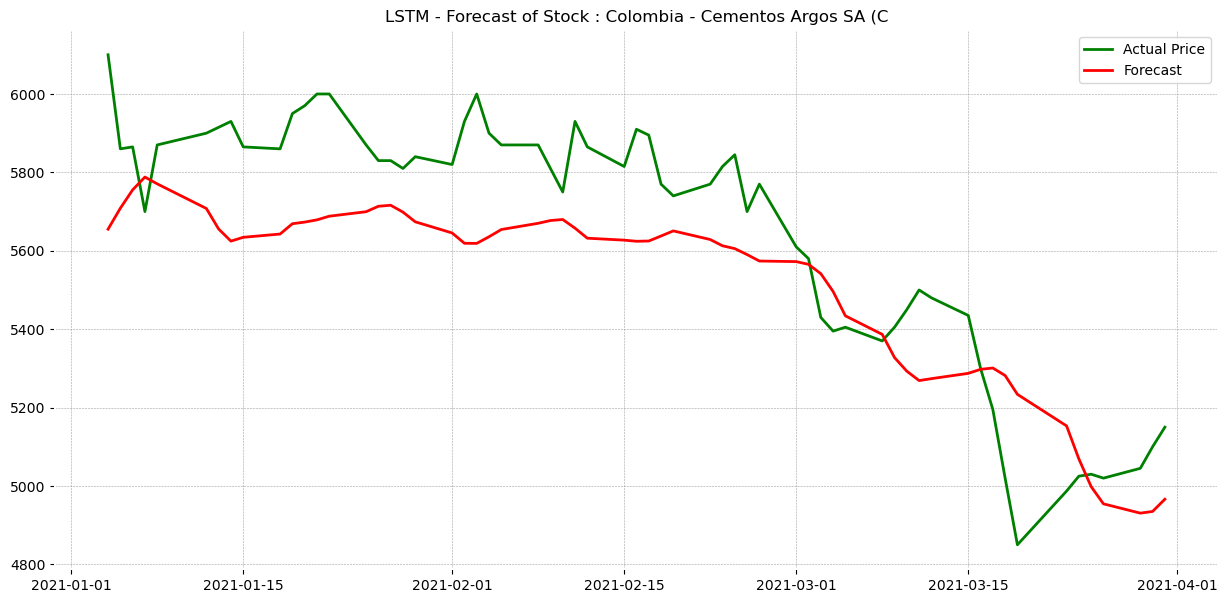

In [46]:
lstm_model_br, forecast_lstm_br = lstm(df_br,name=company_name[5])

2021-03-04 00:00:00: Buy 9.27 stocks @ 5395.00
2021-03-05 00:00:00: Hold stocks
2021-03-08 00:00:00: Hold stocks
2021-03-09 00:00:00: Hold stocks
2021-03-10 00:00:00: Hold stocks
2021-03-11 00:00:00: Hold stocks
2021-03-12 00:00:00: Hold stocks
2021-03-15 00:00:00: Hold stocks
2021-03-16 00:00:00: Hold stocks
2021-03-17 00:00:00: Hold stocks
2021-03-18 00:00:00: Hold stocks
2021-03-19 00:00:00: Stoploss trigger: Sell @ 4850.00
Estimated Returns:44949.03, Estimated Gain/Loss:-5050.97
2021-03-23 00:00:00: Buy 9.01 stocks @ 4987.00
2021-03-24 00:00:00: Hold stocks
2021-03-25 00:00:00: Hold stocks
2021-03-26 00:00:00: Hold stocks
2021-03-29 00:00:00: Hold stocks
2021-03-30 00:00:00: Hold stocks
2021-03-31 00:00:00: Hold stocks
Return of capital is -10.1%


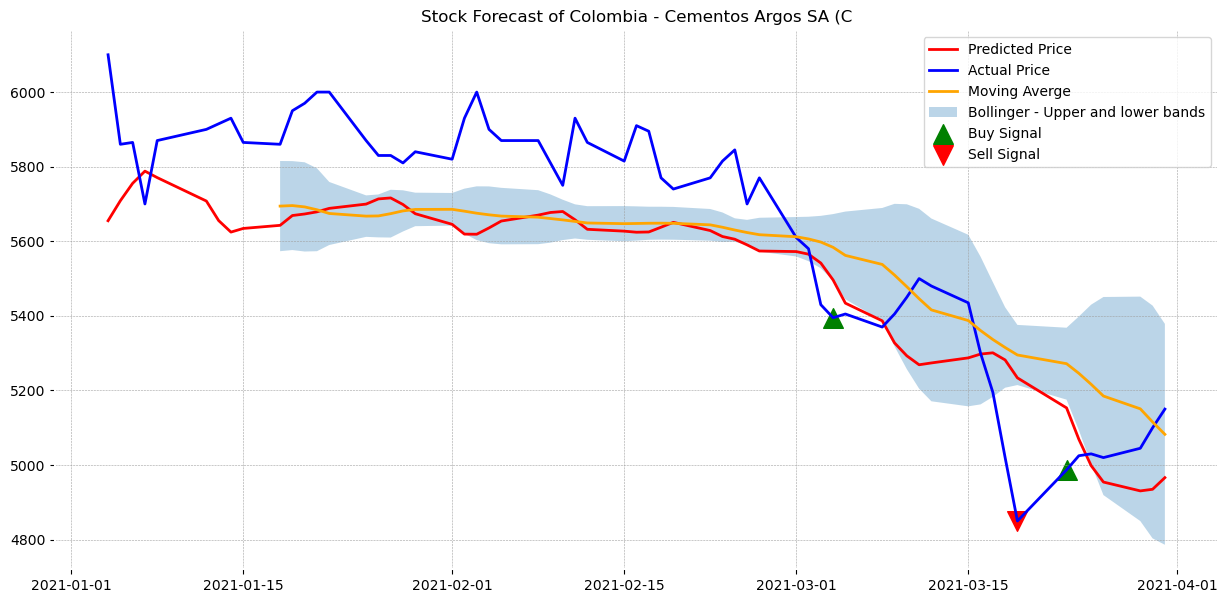

In [47]:
trading_algo(rolling_window=10,forecast=forecast_lstm_br,stoploss=.1,initial_capital=50000,LB_threshold = 0.001,max_hold=5,min_margin=0.1,name=company_name[5])

In [61]:
df_dic[company_name[6]].info()
print(df_dic[company_name[6]].tail())
name = company_name[6]

<class 'pandas.core.frame.DataFrame'>
Index: 315 entries, 2021-03-31 00:00:00 to Highest: 29,777
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Price     315 non-null    object 
 1   Open      315 non-null    object 
 2   High      315 non-null    object 
 3   Low       315 non-null    object 
 4   Vol.      314 non-null    object 
 5   Change %  314 non-null    float64
dtypes: float64(1), object(5)
memory usage: 17.2+ KB
                             Price                Open             High  \
Date                                                                      
2020-01-07 00:00:00          14500               14688            14688   
2020-01-06 00:00:00          14620               14985            15045   
2020-01-03 00:00:00          14843               14700            14884   
2020-01-02 00:00:00          14330               14525            14764   
Highest: 29,777      Lowest: 4,476  Difference: 25,301  

In [62]:
df_br= ini_preprocess(df_dic[company_name[6]])

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 314 entries, 2020-01-02 to 2021-03-31
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Price     314 non-null    float64
 1   Open      314 non-null    float64
 2   High      314 non-null    float64
 3   Low       314 non-null    float64
 4   Vol.      314 non-null    float64
 5   Change %  314 non-null    float64
dtypes: float64(6)
memory usage: 17.2 KB
              Price     Open     High      Low       Vol.  Change %
Date                                                               
2021-03-25  26564.0  25954.0  27128.0  25954.0  2830000.0    0.0255
2021-03-26  27533.0  27083.0  28006.0  26728.0  3360000.0    0.0365
2021-03-29  26980.0  27800.0  28174.0  26614.0  4440000.0   -0.0201
2021-03-30  26898.0  26766.0  27443.0  26360.0  3020000.0   -0.0030
2021-03-31  27373.0  26980.0  27526.0  26657.0  2490000.0    0.0177


scaled price dataset (314, 1)
scaled tensor (308, 6, 1) (308, 1)
training (196, 6, 1) (196, 1)
validation (50, 6, 1) (50, 1)
test (62, 6, 1) (62, 1)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_9 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.1310 - root_mean_squared_error: 0.3616 - val_loss: 0.1484 - val_root_mean_squared_error: 0.3852
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0498 - root_mean_squared_error: 0.2226 - val_loss: 0.0420 - val_root_mean_squared_error: 0.2050
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0103 - root_mean_squared_error: 0.1007 - val_loss: 0.0028 - val_root_mean_squared_error: 0.0529
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0078 - root_mean_squared_error: 0.0880 - val_loss: 0.0023 - val_root_mean_squared_error: 0.0475
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0066 - root_mean_squared_error: 0.0813 - val_loss: 0.0065 - val_root_mean_squared_error: 0.0809
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0040 - root_mean_squared_error: 0.0632 - val_loss: 0.0110 - val_root_mean_squared_error: 0.1051
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0044 - root_mean_

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0023 - root_mean_squared_error: 0.0481 - val_loss: 0.0019 - val_root_mean_squared_error: 0.0435
Epoch 45/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0023 - root_mean_squared_error: 0.0480 - val_loss: 0.0018 - val_root_mean_squared_error: 0.0418
Epoch 46/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0022 - root_mean_squared_error: 0.0468 - val_loss: 0.0021 - val_root_mean_squared_error: 0.0457
Epoch 47/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0020 - root_mean_squared_error: 0.0444 - val_loss: 0.0020 - val_root_mean_squared_error: 0.0442
Epoch 48/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0018 - root_mean_squared_error: 0.0418 - val_loss: 0.0018 - val_root_mean_squared_error: 0.0425
Epoch 49/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0022 - root_mean_squared_error: 0.0464 - val_loss: 0.0019 - val_root_mean_squared_error: 0.0431
Epoch 50/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0019 - root_mean_square

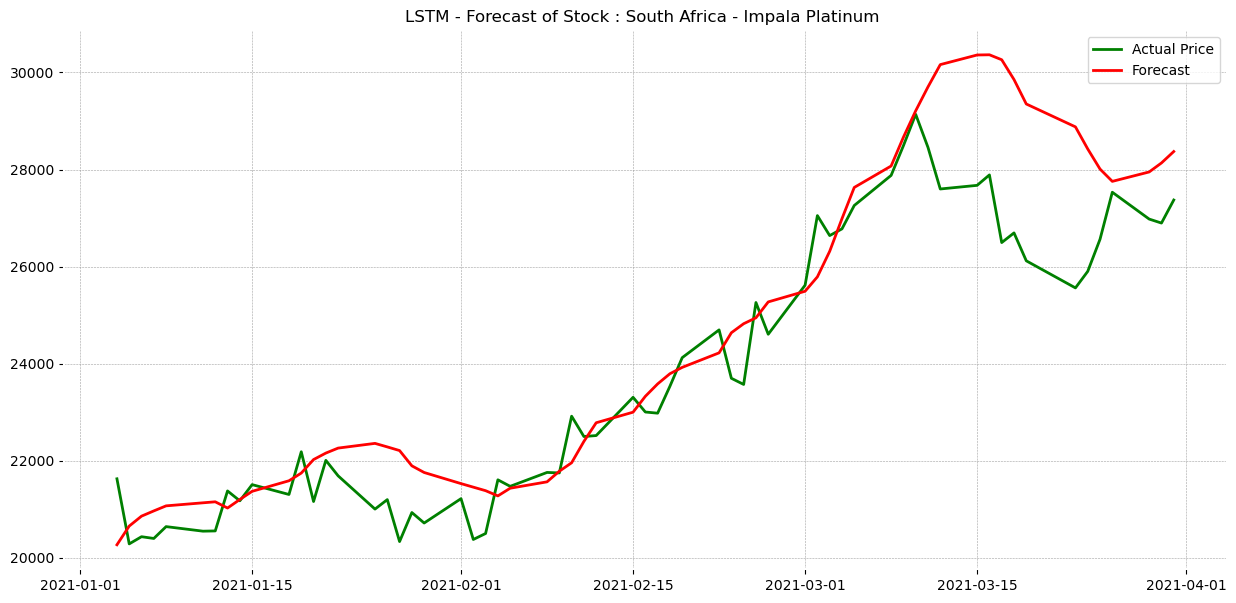

In [63]:
lstm_model_br, forecast_lstm_br = lstm(df_br,name=company_name[6])

2021-02-03 00:00:00: Buy 2.44 stocks @ 20502.00
2021-02-04 00:00:00: Hold stocks
2021-02-05 00:00:00: Hold stocks
2021-02-08 00:00:00: Hold stocks
2021-02-09 00:00:00: Hold stocks
2021-02-10 00:00:00: Sell @ 22919.0
Estimated Returns:55894.55, Estimated Gain/Loss:5894.55
2021-03-23 00:00:00: Buy 2.19 stocks @ 25562.00
2021-03-24 00:00:00: Hold stocks
2021-03-25 00:00:00: Hold stocks
2021-03-26 00:00:00: Hold stocks
2021-03-29 00:00:00: Hold stocks
2021-03-30 00:00:00: Hold stocks
2021-03-31 00:00:00: Hold stocks
Return of capital is 11.8%


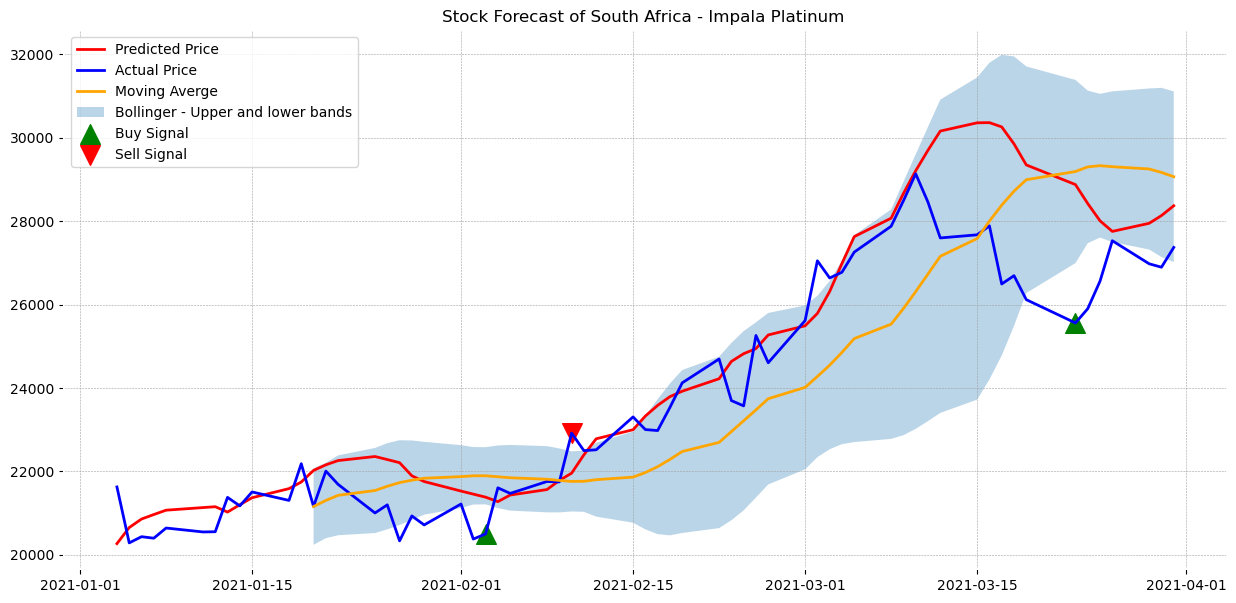

In [66]:
trading_algo(rolling_window=13,forecast=forecast_lstm_br,stoploss=.1,initial_capital=50000,LB_threshold = 0.001,max_hold=5,min_margin=0.1,name=company_name[6])

In [77]:
df_dic[company_name[7]].info()
print(df_dic[company_name[7]].tail())
name = company_name[7]

<class 'pandas.core.frame.DataFrame'>
Index: 342 entries, 2021-03-31 00:00:00 to Highest: 14,200
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Price     342 non-null    object 
 1   Open      342 non-null    object 
 2   High      342 non-null    object 
 3   Low       342 non-null    object 
 4   Vol.      341 non-null    object 
 5   Change %  341 non-null    float64
dtypes: float64(1), object(5)
memory usage: 18.7+ KB
                             Price                Open            High  \
Date                                                                     
2020-01-07 00:00:00           5690                5740            5770   
2020-01-06 00:00:00           5730                5890            5890   
2020-01-03 00:00:00           5900                5870            5920   
2020-01-02 00:00:00           5850                5930            5980   
Highest: 14,200      Lowest: 2,780  Difference: 11,420  Averag

In [78]:
df_br= ini_preprocess(df_dic[company_name[7]])

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 341 entries, 2020-01-02 to 2021-03-31
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Price     341 non-null    float64
 1   Open      341 non-null    float64
 2   High      341 non-null    float64
 3   Low       341 non-null    float64
 4   Vol.      341 non-null    float64
 5   Change %  341 non-null    float64
dtypes: float64(6)
memory usage: 18.6 KB
              Price     Open     High      Low       Vol.  Change %
Date                                                               
2021-03-26  12200.0  11500.0  12300.0  11350.0  2340000.0    0.0796
2021-03-28  12200.0  12200.0  12200.0  12200.0        0.0    0.0000
2021-03-29  13550.0  12500.0  13800.0  12500.0      200.0    0.1107
2021-03-30  13650.0  13850.0  14200.0  13050.0  3170000.0    0.0074
2021-03-31  13650.0  13700.0  13750.0  13450.0      190.0    0.0000


scaled price dataset (341, 1)
scaled tensor (335, 6, 1) (335, 1)
training (212, 6, 1) (212, 1)
validation (54, 6, 1) (54, 1)
test (69, 6, 1) (69, 1)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_11 (LSTM)                  │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0526 - root_mean_squared_error: 0.2287 - val_loss: 0.0673 - val_root_mean_squared_error: 0.2594
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0140 - root_mean_squared_error: 0.1176 - val_loss: 0.0079 - val_root_mean_squared_error: 0.0886
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0044 - root_mean_squared_error: 0.0659 - val_loss: 0.0010 - val_root_mean_squared_error: 0.0317
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0055 - root_mean_squared_error: 0.0738 - val_loss: 0.0051 - val_root_mean_squared_error: 0.0716
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0033 - root_mean_squared_error: 0.0571 - val_loss: 0.0119 - val_root_mean_squared_error: 0.1089
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0036 - root_mean_squared_error: 0.0596 - val_loss: 0.0100 - val_root_mean_squared_error: 0.1002
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0027 - root_mean_

Epoch 44/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0012 - root_mean_squared_error: 0.0339 - val_loss: 8.4850e-04 - val_root_mean_squared_error: 0.0291
Epoch 45/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 9.6119e-04 - root_mean_squared_error: 0.0309 - val_loss: 7.1297e-04 - val_root_mean_squared_error: 0.0267
Epoch 46/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 9.7502e-04 - root_mean_squared_error: 0.0308 - val_loss: 7.2007e-04 - val_root_mean_squared_error: 0.0268
Epoch 47/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0010 - root_mean_squared_error: 0.0312 - val_loss: 7.9692e-04 - val_root_mean_squared_error: 0.0282
Epoch 48/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9.5074e-04 - root_mean_squared_error: 0.0303 - val_loss: 6.7870e-04 - val_root_mean_squared_error: 0.0261
Epoch 49/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0011 - root_mean_squared_error: 0.0324 - val_loss: 8.2700e-04 - val_root_mean_squared_error: 0.0288
Epoch 50/50
7/7 ━━━━━━━━━━━━━━━━━━

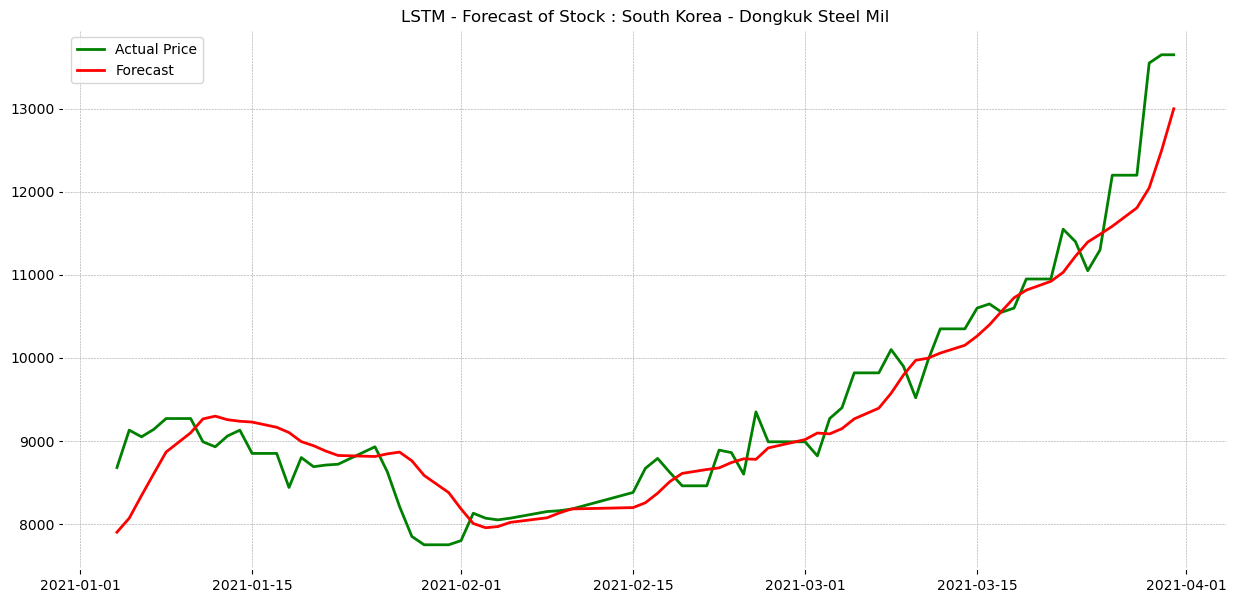

In [79]:
lstm_model_br, forecast_lstm_br = lstm(df_br,name=company_name[7])

2021-01-27 00:00:00: Buy 6.09 stocks @ 8210.00
2021-01-28 00:00:00: Hold stocks
2021-01-29 00:00:00: Hold stocks
2021-01-31 00:00:00: Hold stocks
2021-02-01 00:00:00: Hold stocks
2021-02-02 00:00:00: Hold stocks
2021-02-03 00:00:00: Hold stocks
2021-02-04 00:00:00: Hold stocks
2021-02-05 00:00:00: Hold stocks
2021-02-08 00:00:00: Hold stocks
2021-02-09 00:00:00: Hold stocks
2021-02-10 00:00:00: Hold stocks
2021-02-15 00:00:00: Hold stocks
2021-02-16 00:00:00: Hold stocks
2021-02-17 00:00:00: Hold stocks
2021-02-18 00:00:00: Hold stocks
2021-02-19 00:00:00: Hold stocks
2021-02-21 00:00:00: Hold stocks
2021-02-22 00:00:00: Hold stocks
2021-02-23 00:00:00: Hold stocks
2021-02-24 00:00:00: Hold stocks
2021-02-25 00:00:00: Sell @ 9350.0
Estimated Returns:56942.75, Estimated Gain/Loss:6942.75
Return of capital is 13.9%


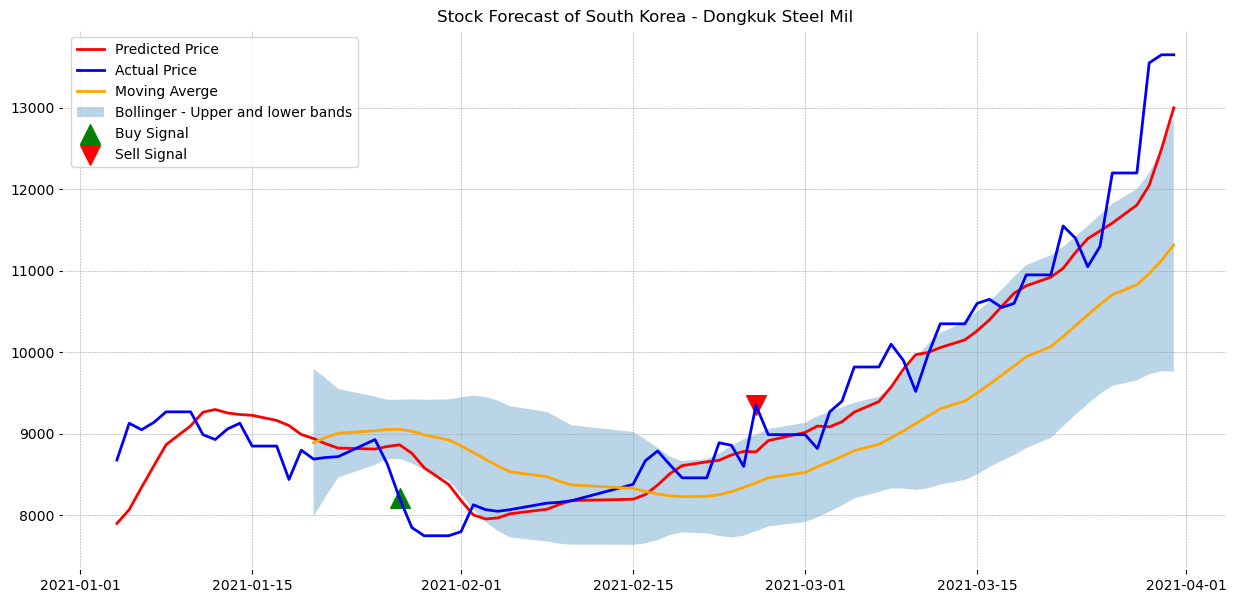

In [84]:
trading_algo(rolling_window=15,forecast=forecast_lstm_br,stoploss=.15,initial_capital=50000,LB_threshold = 0.001,max_hold=5,min_margin=0.1,name=company_name[7])

Three additional parameters provide more control over trade decisions, specific conditions are employed to assess the trend. Depending on the forecasted trend, we can adjust the thresholds inorder to ensure maximum returns and minimal losses. For example, a minimum margin parameter of 1% might be applied for a downward trend, while 8-10% could be utilized for an upward trend.

For a buy signal, it verifies whether the previous closing price is below the lower Bollinger Band, and the current price is within a specified threshold above the lower Bollinger Band.
For a sell signal, it examines whether the current price surpasses the upper Bollinger Band or if the maximum holding period has been reached. Additionally, it checks if the current price is above a minimum margin from the locked price. 
The inclusion of a Minimum margin is empoyed to ensforce the maximum possible profit.
The trailing stop feature automatically adjusts the stop-loss mark based on the current price. If the current price falls below a certain percentage of the stop-loss price, a stop-loss trigger is activated. 
Consequently, stocks are sold, and the available capital is updated, thus minimizing losses.